In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
import time, json, warnings
from datetime import timedelta
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# ── Output directory ──────────────────────────────────────
OUT_DIR = '/kaggle/working/model2_improved/'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Custom color palette (different from original) ────────
COLORS = {
    'primary'    : '#6A0572',   # deep purple
    'secondary'  : '#F4A261',   # warm orange
    'accent'     : '#2A9D8F',   # teal
    'highlight'  : '#E9C46A',   # golden yellow
    'danger'     : '#E76F51',   # burnt orange
    'cool'       : '#264653',   # dark teal
    'light'      : '#A8DADC',   # light blue
    'pink'       : '#E63946',   # vivid red
}
PALETTE = list(COLORS.values())

# Set global style
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'figure.dpi'        : 120,
})

print('TensorFlow:', tf.__version__)
print('Output dir :', OUT_DIR)
print('All imports OK')

2026-03-28 09:28:28.025699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774690108.274069      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774690108.345754      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774690108.927541      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774690108.927596      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774690108.927601      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Output dir : /kaggle/working/model2_improved/
All imports OK


In [4]:
start_load = time.time()

interaction_data = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv')
presentations    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv')
presentations_df = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv')
ratings_matrix   = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv')
recommendations  = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv')
user_profiles    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv')

print(f'Loaded in {time.time()-start_load:.2f}s')
for name, df_ in [('interaction_data', interaction_data), ('ratings_matrix', ratings_matrix),
                   ('recommendations', recommendations), ('user_profiles', user_profiles),
                   ('presentations', presentations)]:
    print(f'  {name:20s}: {df_.shape}')

Loaded in 0.24s
  interaction_data    : (25000, 75)
  ratings_matrix      : (3000, 5)
  recommendations     : (100, 26)
  user_profiles       : (30, 5)
  presentations       : (78, 15)


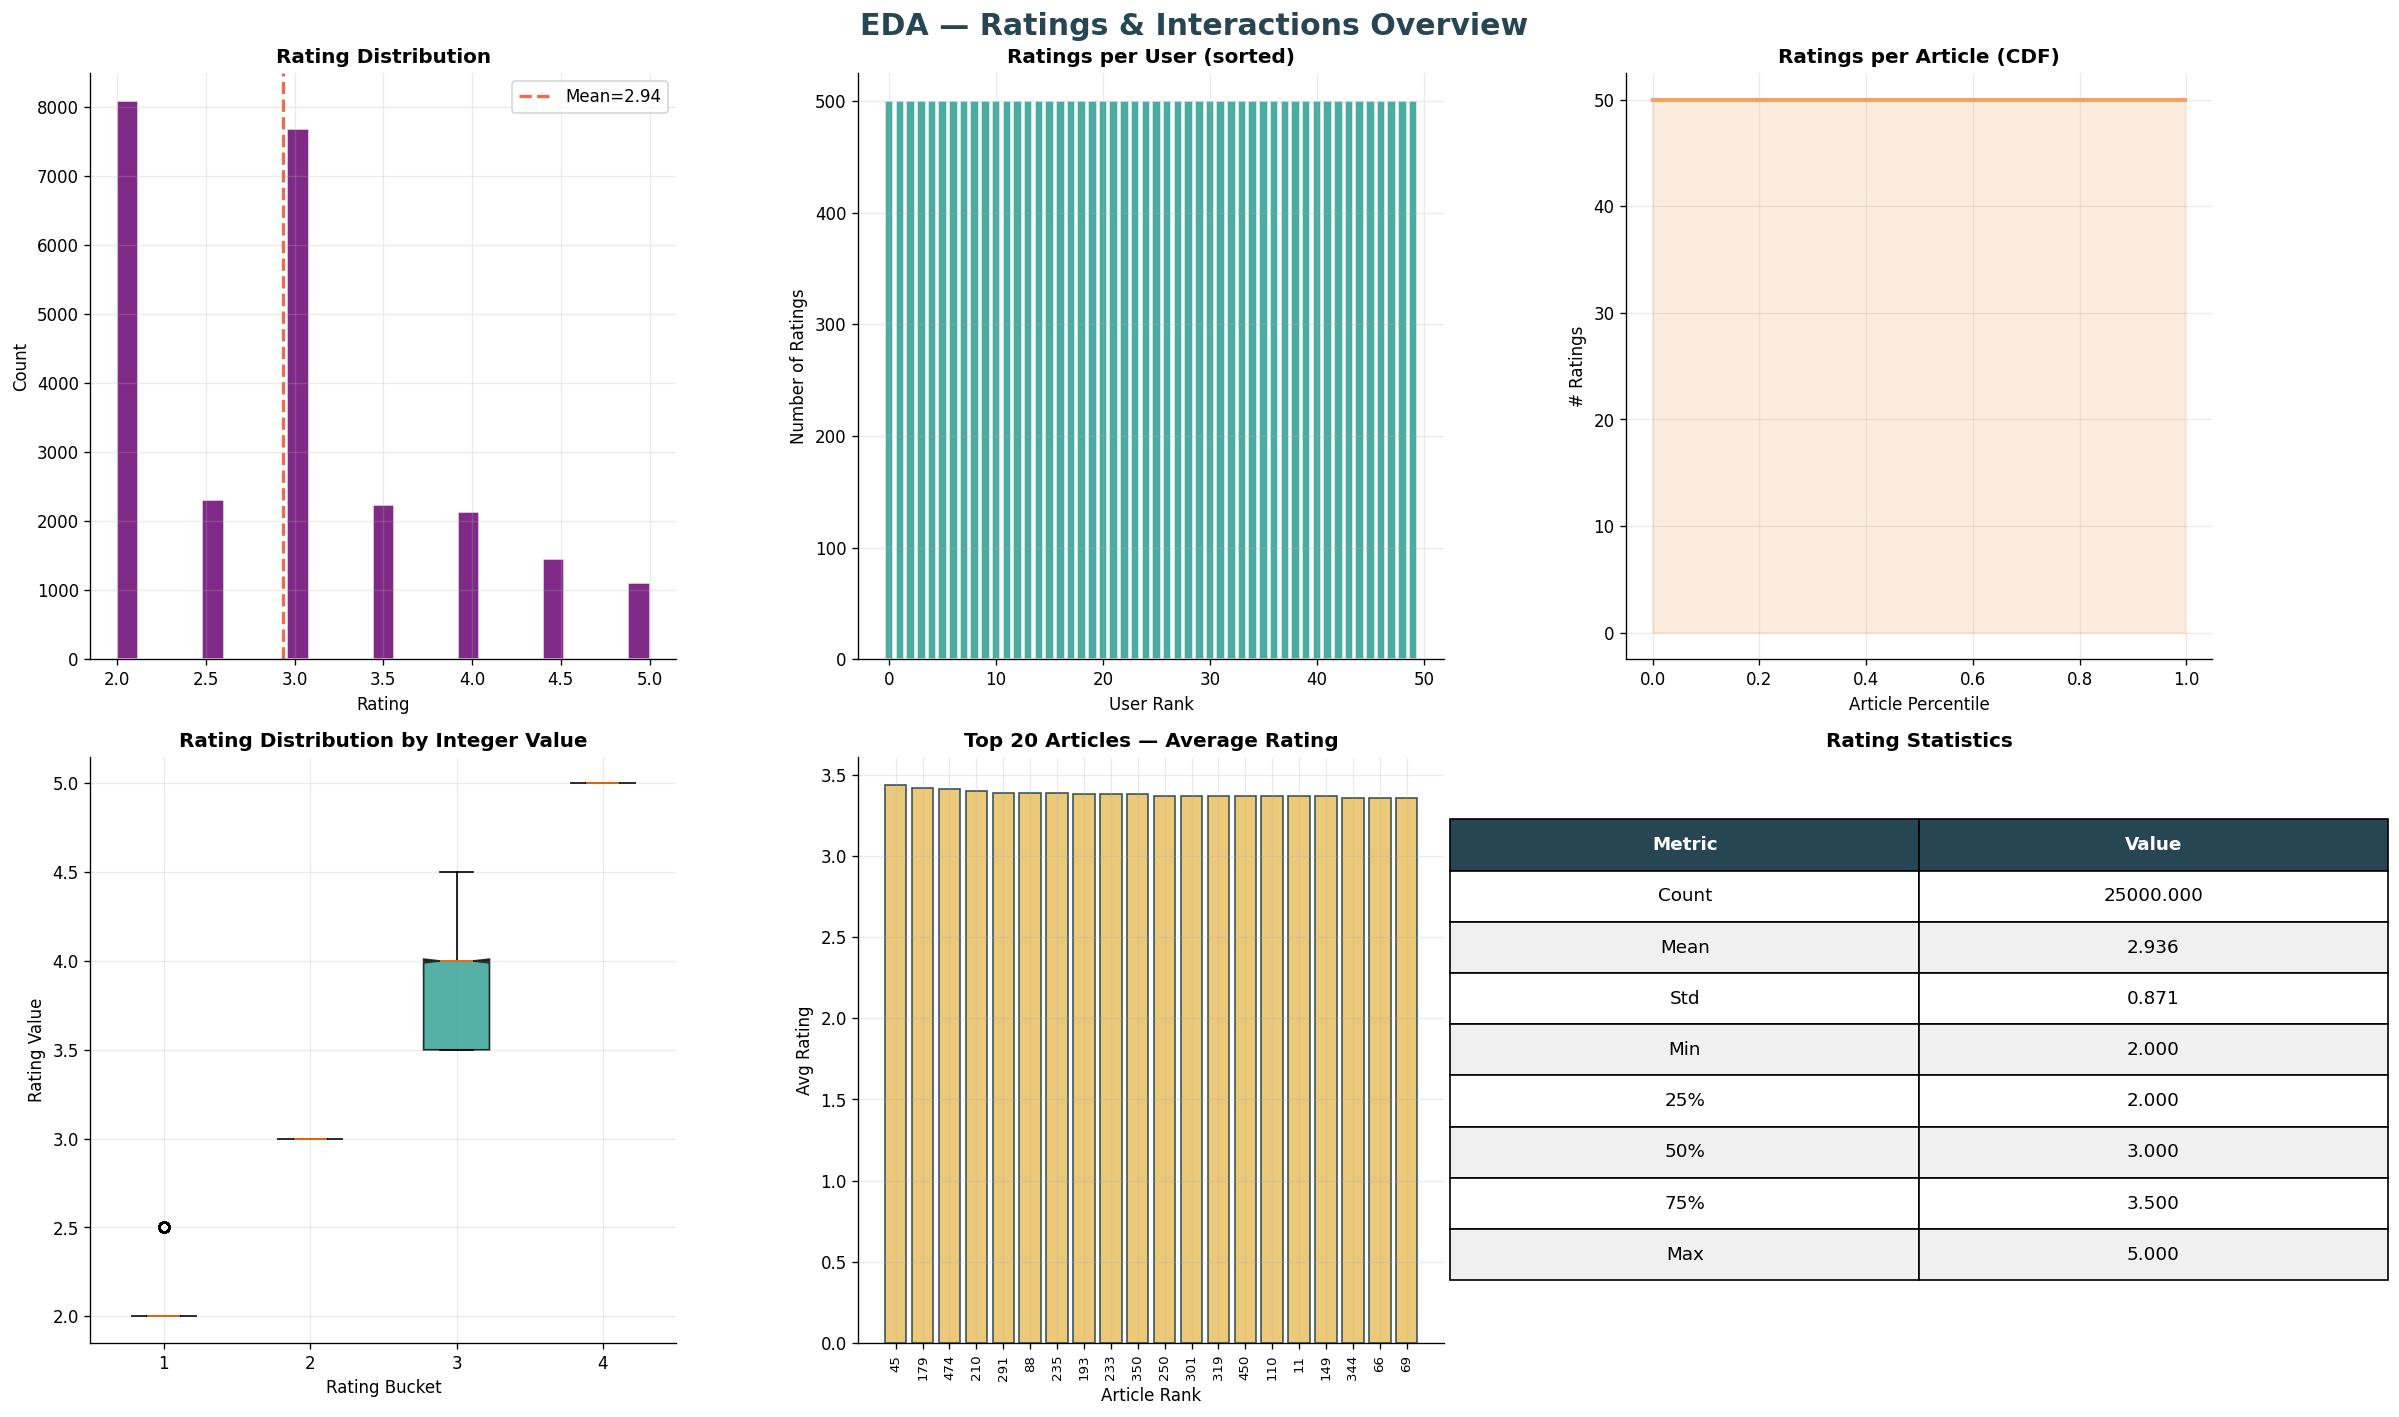

Saved: eda_01_ratings_overview.png


In [5]:
# ── EDA Figure 1: Ratings & Interaction Overview ──────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=18,
             fontweight='bold', color=COLORS['cool'])

# 1. Rating distribution — violin + strip
axes[0,0].hist(interaction_data['rating'], bins=25,
               color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[0,0].axvline(interaction_data['rating'].mean(), color=COLORS['danger'],
                  linestyle='--', linewidth=2, label=f'Mean={interaction_data["rating"].mean():.2f}')
axes[0,0].set_title('Rating Distribution', fontweight='bold')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Ratings per user (sorted)
rpu = interaction_data.groupby('user_id')['rating'].count().sort_values(ascending=False)
axes[0,1].bar(range(len(rpu)), rpu.values,
              color=COLORS['accent'], edgecolor='white', alpha=0.85)
axes[0,1].set_title('Ratings per User (sorted)', fontweight='bold')
axes[0,1].set_xlabel('User Rank')
axes[0,1].set_ylabel('Number of Ratings')

# 3. Ratings per article — CDF
rpa = interaction_data.groupby('article_id')['rating'].count().sort_values()
axes[0,2].plot(np.arange(len(rpa))/len(rpa), rpa.values,
               color=COLORS['secondary'], linewidth=2.5)
axes[0,2].fill_between(np.arange(len(rpa))/len(rpa), rpa.values,
                        alpha=0.2, color=COLORS['secondary'])
axes[0,2].set_title('Ratings per Article (CDF)', fontweight='bold')
axes[0,2].set_xlabel('Article Percentile')
axes[0,2].set_ylabel('# Ratings')

# 4. Box plot of ratings by rating integer value
rating_groups = [interaction_data[interaction_data['rating'].round()==r]['rating'].values
                 for r in sorted(interaction_data['rating'].round().unique())]
bp = axes[1,0].boxplot(rating_groups, patch_artist=True,
                        notch=True, vert=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1,0].set_title('Rating Distribution by Integer Value', fontweight='bold')
axes[1,0].set_xlabel('Rating Bucket')
axes[1,0].set_ylabel('Rating Value')

# 5. Top 20 articles by avg rating
top_art = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
bars5 = axes[1,1].bar(range(len(top_art)), top_art.values,
                       color=COLORS['highlight'], edgecolor=COLORS['cool'], alpha=0.9)
axes[1,1].set_title('Top 20 Articles — Average Rating', fontweight='bold')
axes[1,1].set_xlabel('Article Rank')
axes[1,1].set_ylabel('Avg Rating')
axes[1,1].set_xticks(range(len(top_art)))
axes[1,1].set_xticklabels([str(a) for a in top_art.index], rotation=90, fontsize=8)

# 6. Summary statistics table
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k.capitalize(), f'{v:.3f}'] for k, v in stats.items()]
tbl = axes[1,2].table(cellText=table_data, colLabels=['Metric', 'Value'],
                       loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.6, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['cool'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F0F0')
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_01_ratings_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_01_ratings_overview.png')

In [7]:
# ── Merge for EDA ─────────────────────────────────────────
df_merged = interaction_data.copy()
df_merged = df_merged.merge(
    user_profiles[['user_id','type','location','preferences','preferred_presentation_type']],
    on='user_id', how='left', suffixes=('','_user')
)
df_merged = df_merged.merge(
    recommendations[['article_id','presentation_type','audience_type','Main issue','popularity']],
    on='article_id', how='left', suffixes=('','_rec')
)
print(f'Merged shape: {df_merged.shape}')

Merged shape: (25000, 83)


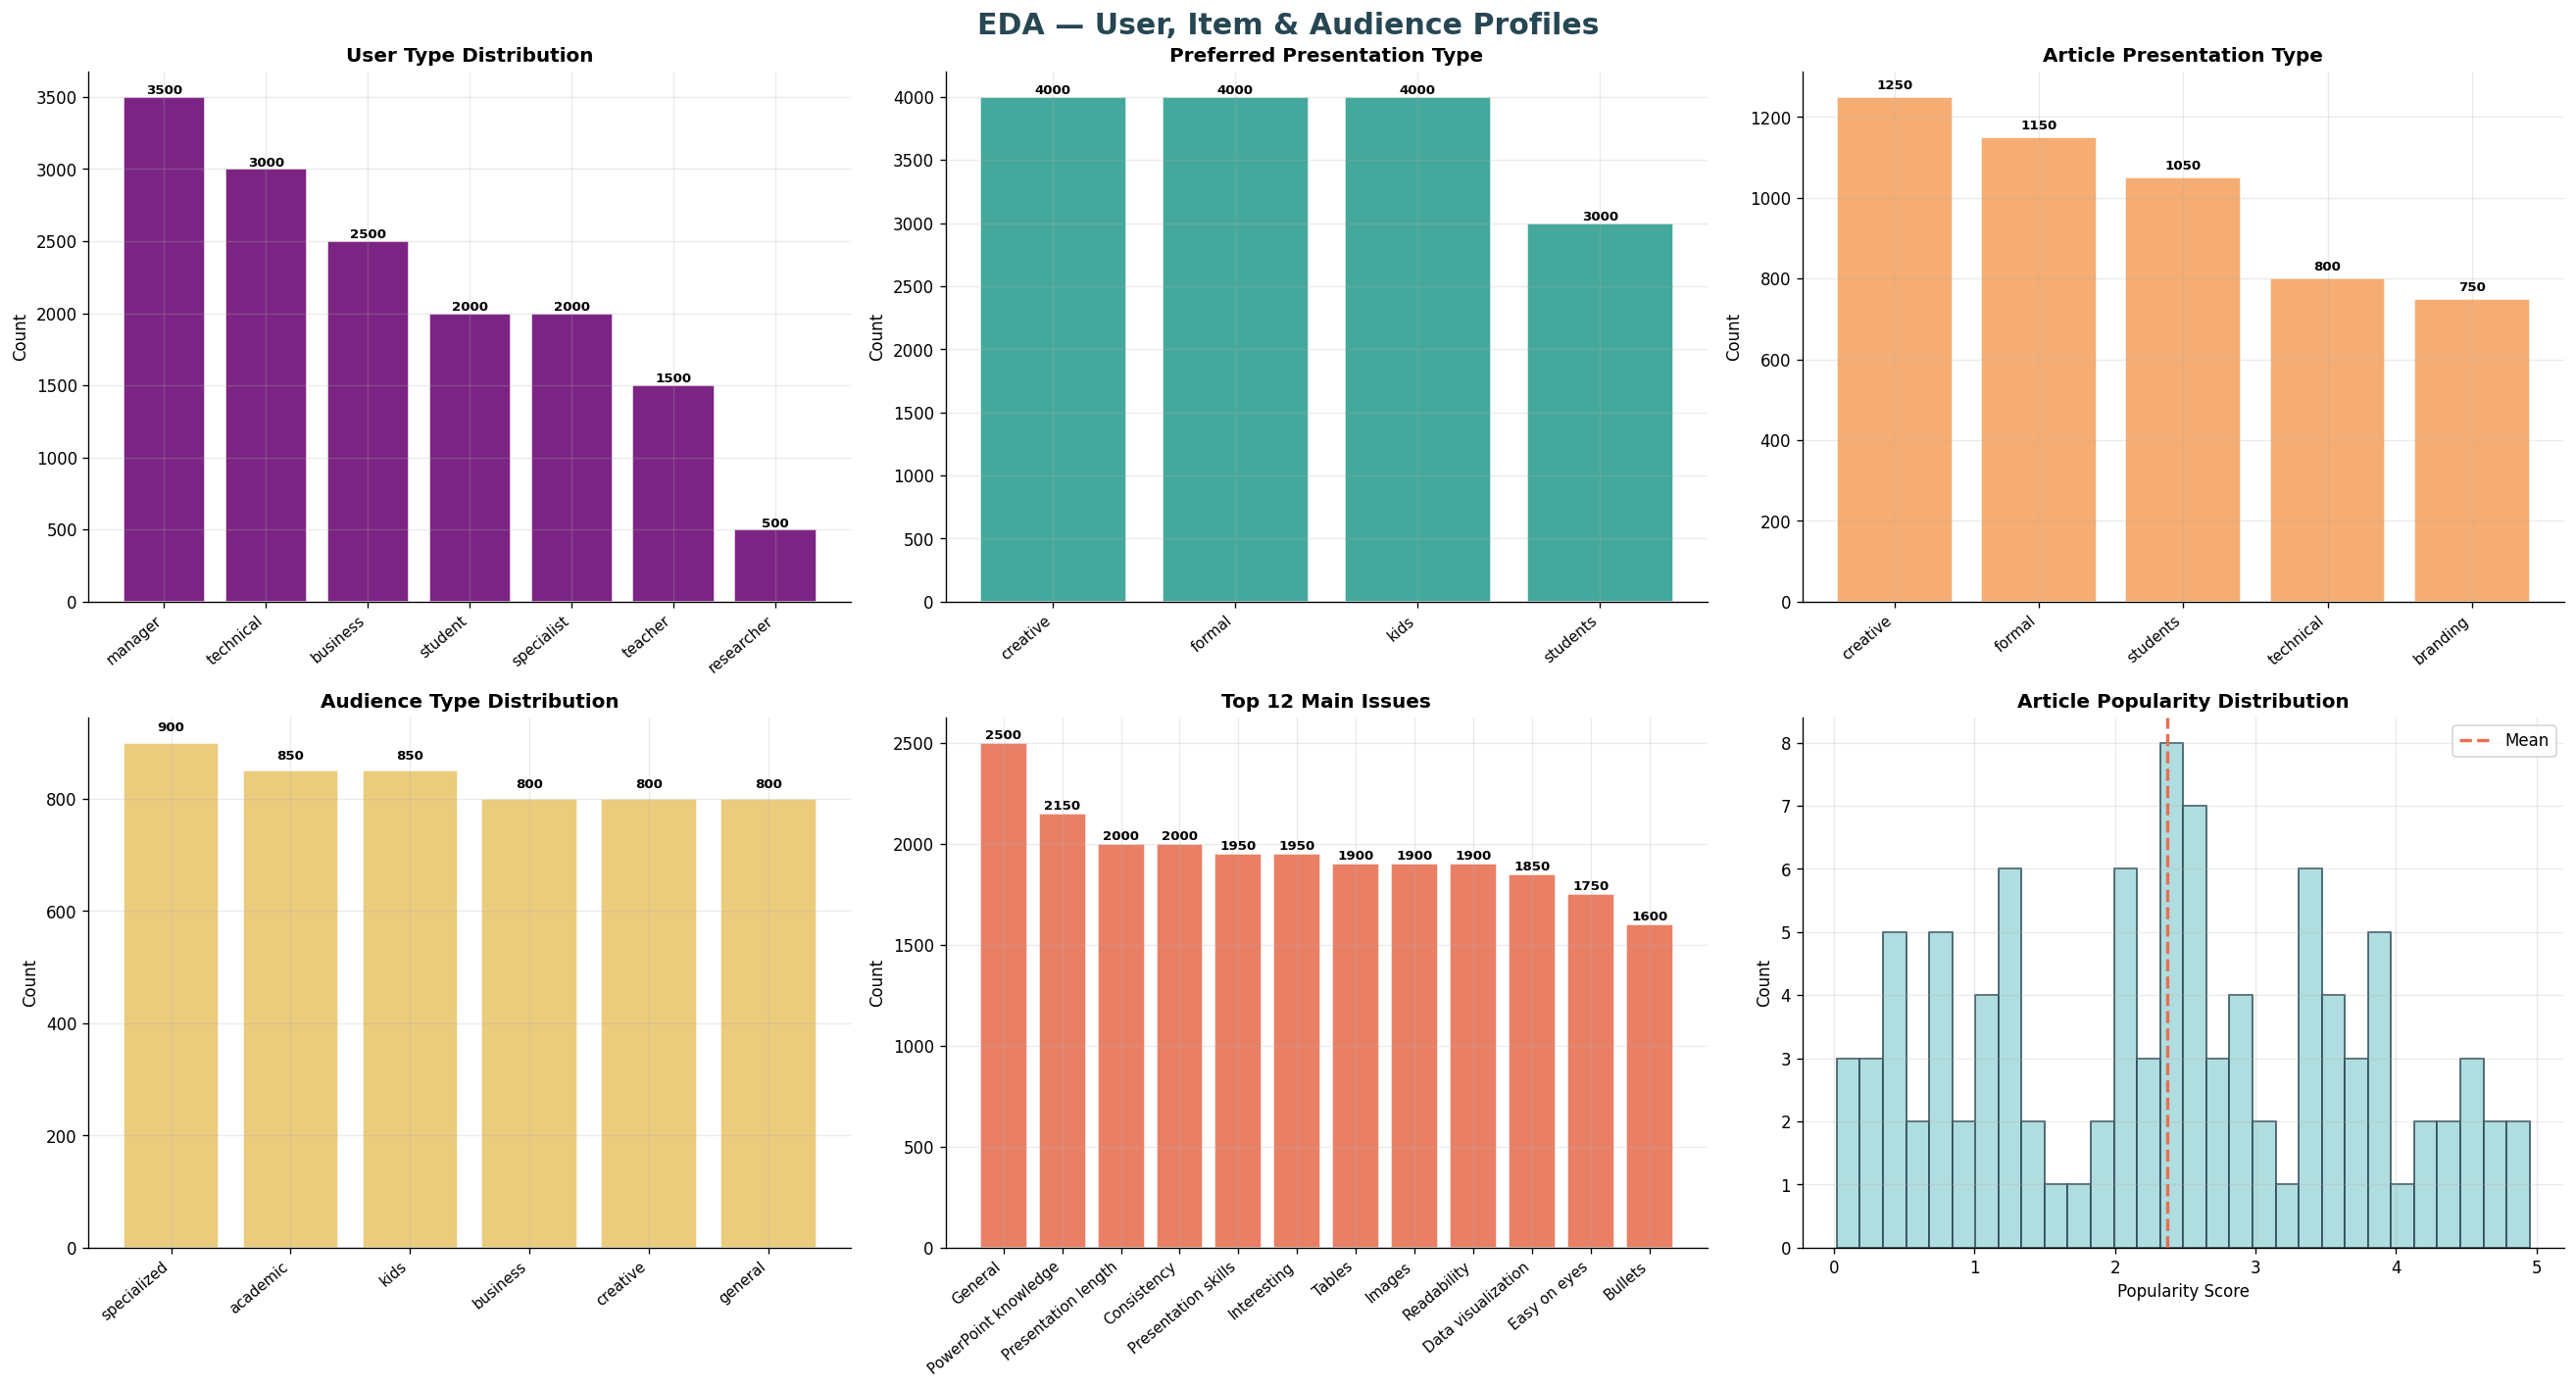

Saved: eda_02_categorical_distributions.png


In [8]:
# ── EDA Figure 2: User & Item Categorical Distributions ───
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('EDA — User, Item & Audience Profiles', fontsize=18,
             fontweight='bold', color=COLORS['cool'])

cat_plots = [
    (axes[0,0], df_merged['type'].value_counts(),           'User Type Distribution',              COLORS['primary']),
    (axes[0,1], df_merged['preferred_presentation_type'].value_counts(), 'Preferred Presentation Type',   COLORS['accent']),
    (axes[0,2], df_merged['presentation_type'].value_counts(),           'Article Presentation Type',     COLORS['secondary']),
    (axes[1,0], df_merged['audience_type'].value_counts(),               'Audience Type Distribution',    COLORS['highlight']),
    (axes[1,1], df_merged['Main issue'].value_counts().head(12),         'Top 12 Main Issues',            COLORS['danger']),
]

for ax, data, title, color in cat_plots:
    bars = ax.bar(range(len(data)), data.values, color=color, edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(val), ha='center', fontsize=8, fontweight='bold')

# Popularity distribution
axes[1,2].hist(recommendations['popularity'], bins=30,
               color=COLORS['light'], edgecolor=COLORS['cool'], alpha=0.9)
axes[1,2].axvline(recommendations['popularity'].mean(), color=COLORS['danger'],
                  linestyle='--', linewidth=2, label='Mean')
axes[1,2].set_title('Article Popularity Distribution', fontweight='bold')
axes[1,2].set_xlabel('Popularity Score')
axes[1,2].set_ylabel('Count')
axes[1,2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_02_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_02_categorical_distributions.png')

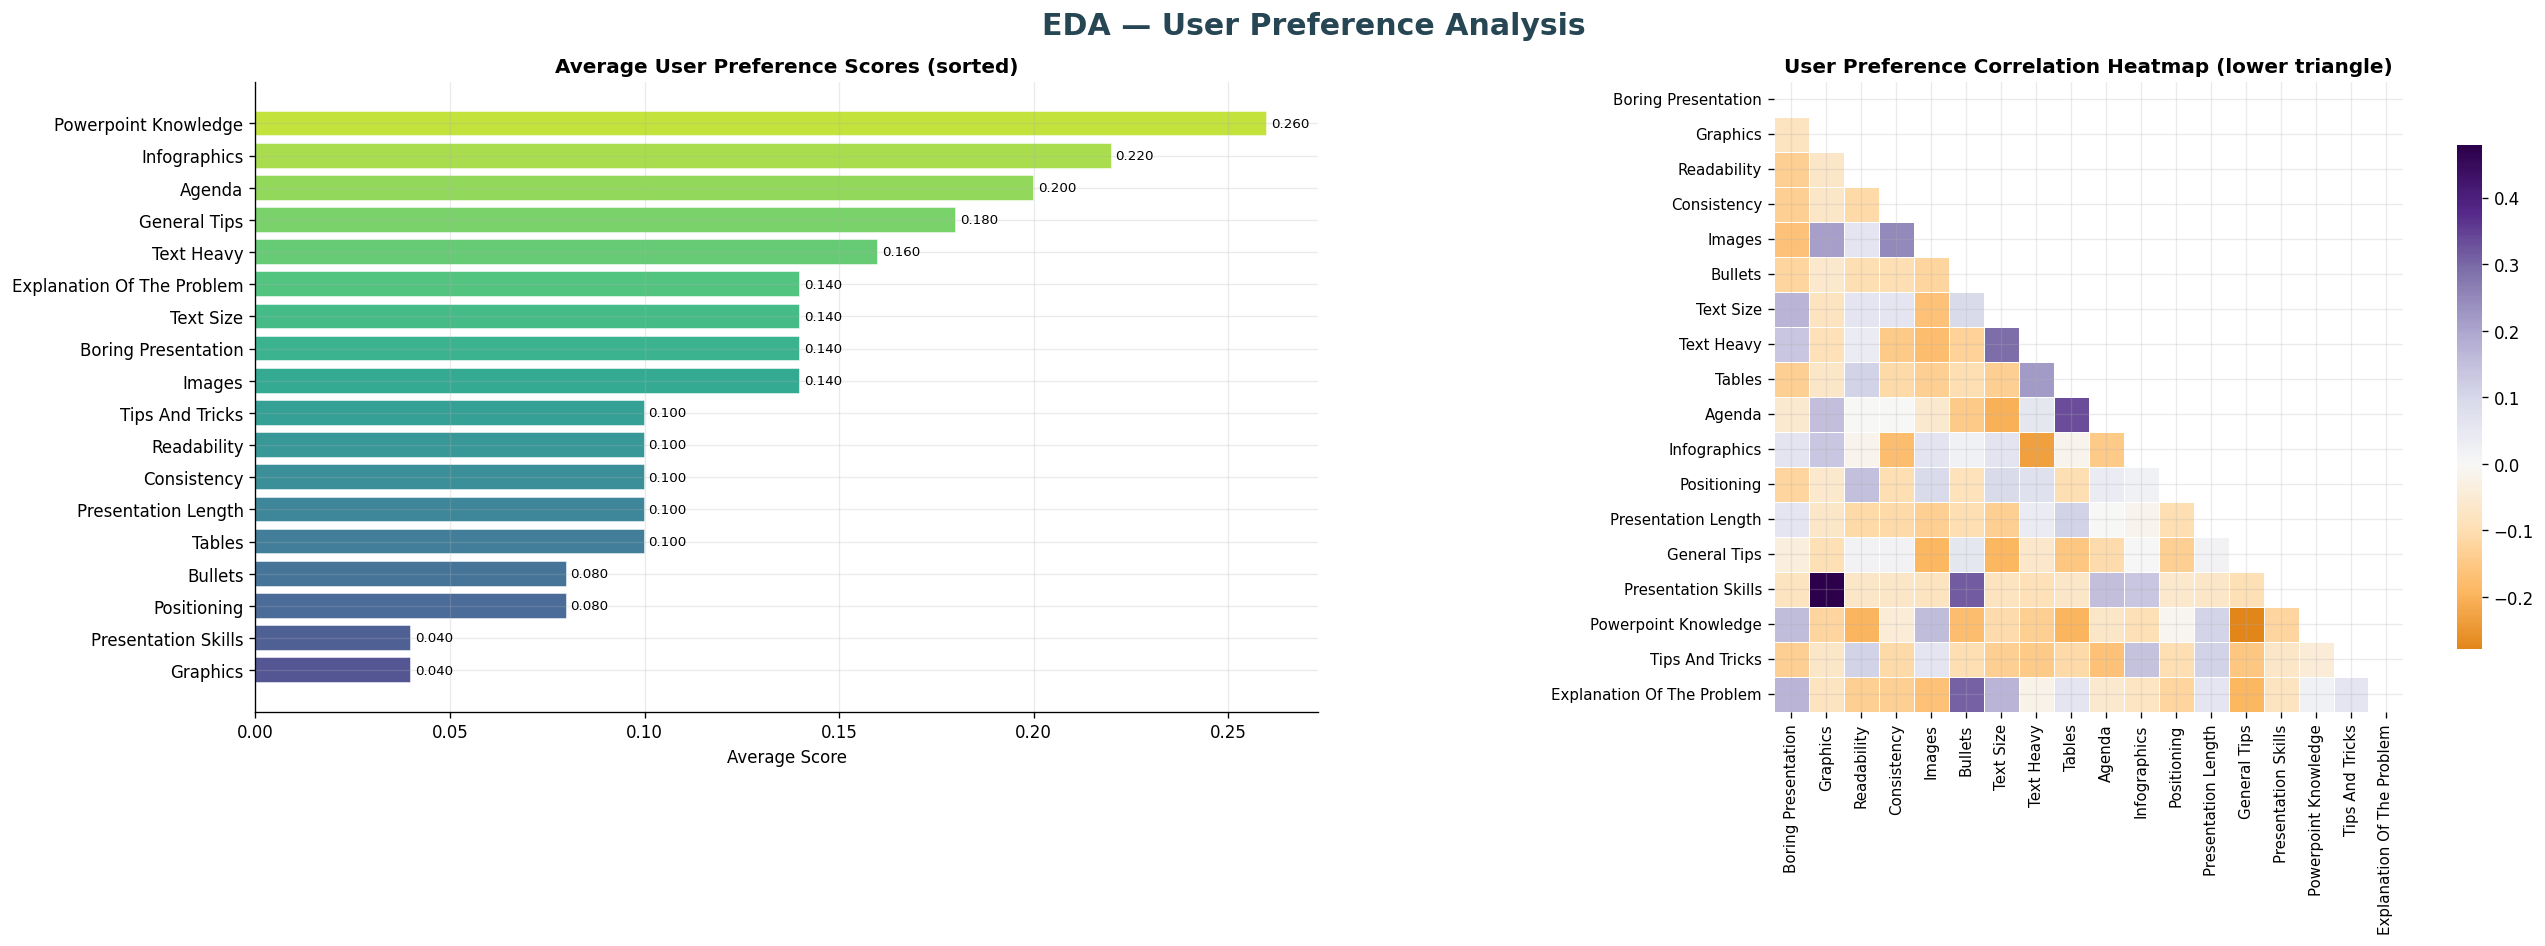

Saved: eda_03_user_preferences.png


In [9]:
# ── EDA Figure 3: User Preferences Heatmap + Avg Prefs ────
pref_cols = [c for c in interaction_data.columns if c.startswith('user_preference_')]
clean_labels = [c.replace('user_preference_', '').replace('_', ' ').title() for c in pref_cols]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('EDA — User Preference Analysis', fontsize=18,
             fontweight='bold', color=COLORS['cool'])

avg_prefs = interaction_data[pref_cols].mean().sort_values(ascending=True)
cmap_vals = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_prefs)))
axes[0].barh(range(len(avg_prefs)), avg_prefs.values,
             color=cmap_vals, edgecolor='white', alpha=0.9)
axes[0].set_yticks(range(len(avg_prefs)))
axes[0].set_yticklabels([c.replace('user_preference_','').replace('_',' ').title()
                          for c in avg_prefs.index], fontsize=10)
axes[0].set_title('Average User Preference Scores (sorted)', fontweight='bold')
axes[0].set_xlabel('Average Score')
for i, v in enumerate(avg_prefs.values):
    axes[0].text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)

pref_corr = interaction_data[pref_cols].corr()
mask = np.triu(np.ones_like(pref_corr, dtype=bool))
sns.heatmap(pref_corr, ax=axes[1], cmap='PuOr', center=0,
            square=True, linewidths=0.4, mask=mask,
            xticklabels=clean_labels, yticklabels=clean_labels,
            annot=False, cbar_kws={'shrink':0.8})
axes[1].set_title('User Preference Correlation Heatmap (lower triangle)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_03_user_preferences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_03_user_preferences.png')

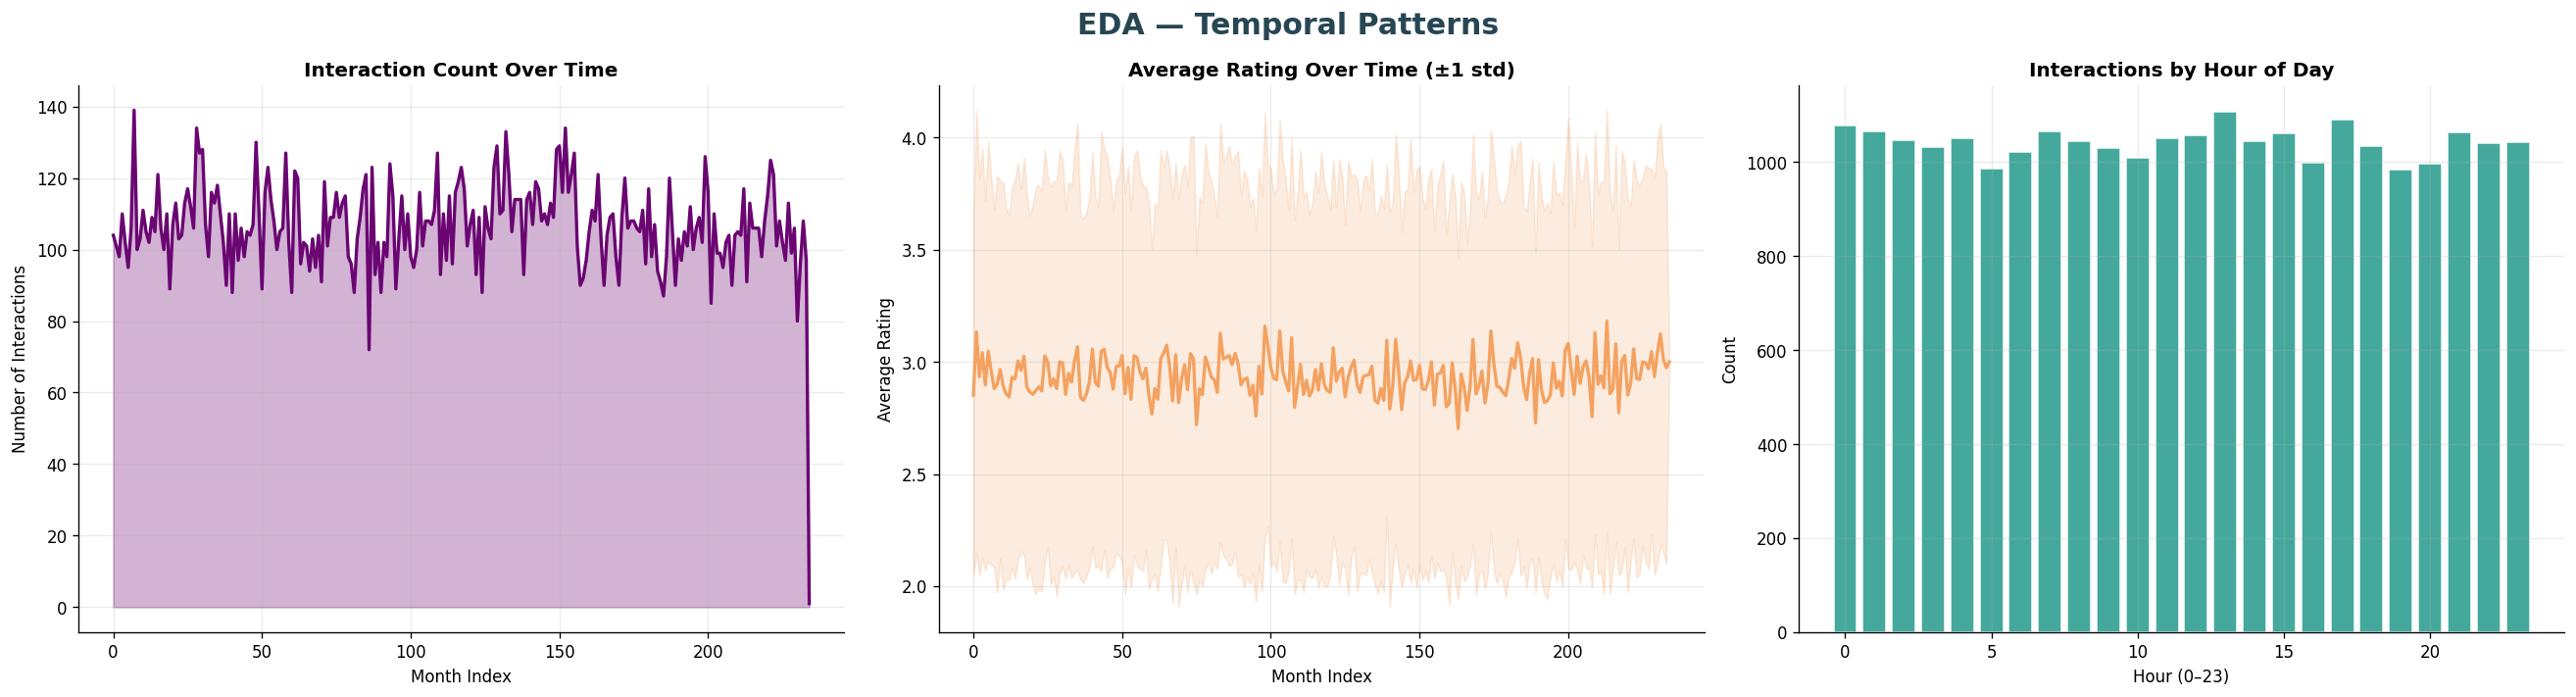

Saved: eda_04_temporal.png


In [10]:
# ── EDA Figure 4: Temporal Analysis ───────────────────────
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])

interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_counts = interaction_data.groupby('year_month').size()
monthly_avg    = interaction_data.groupby('year_month')['rating'].mean()
monthly_std    = interaction_data.groupby('year_month')['rating'].std().fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('EDA — Temporal Patterns', fontsize=18,
             fontweight='bold', color=COLORS['cool'])

x = range(len(monthly_counts))
axes[0].fill_between(x, monthly_counts.values, alpha=0.3, color=COLORS['primary'])
axes[0].plot(x, monthly_counts.values, color=COLORS['primary'], linewidth=2)
axes[0].set_title('Interaction Count Over Time', fontweight='bold')
axes[0].set_xlabel('Month Index')
axes[0].set_ylabel('Number of Interactions')

axes[1].plot(x, monthly_avg.values, color=COLORS['secondary'], linewidth=2)
axes[1].fill_between(x,
                     monthly_avg.values - monthly_std.values,
                     monthly_avg.values + monthly_std.values,
                     alpha=0.2, color=COLORS['secondary'])
axes[1].set_title('Average Rating Over Time (±1 std)', fontweight='bold')
axes[1].set_xlabel('Month Index')
axes[1].set_ylabel('Average Rating')

# Hour of day distribution
interaction_data['hour'] = interaction_data['timestamp'].dt.hour
hour_counts = interaction_data.groupby('hour').size()
axes[2].bar(hour_counts.index, hour_counts.values,
            color=COLORS['accent'], edgecolor='white', alpha=0.88)
axes[2].set_title('Interactions by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour (0–23)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_04_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_04_temporal.png')

In [11]:
print('Starting Feature Engineering...')

df = interaction_data.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month

# Cyclic encoding
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['day_sin']   = np.sin(2*np.pi*df['dayofweek']/7)
df['day_cos']   = np.cos(2*np.pi*df['dayofweek']/7)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

df = df.sort_values('timestamp')
first_ts = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days

# User & item stats
user_stats = df.groupby('user_id').agg(
    user_avg_rating=('rating','mean'),
    user_rating_count=('rating','count'),
    user_rating_std=('rating','std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')

item_stats = df.groupby('article_id').agg(
    item_avg_rating=('rating','mean'),
    item_rating_count=('rating','count'),
    item_rating_std=('rating','std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')

# Match score
pref_cols  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols = ['Boring presentation','Graphics','Readability','Consistency',
              'Images','Bullets','Text size','Text heavy','Tables',
              'Agenda','Infographics','Positioning']

def compute_match(row):
    return sum(int(row[p]==row[i]) for p,i in zip(pref_cols, issue_cols) if i in row.index)

tqdm.pandas(desc='Computing match scores')
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)

# Improved decay rate (tuned)
decay_rate = 0.008
df['time_decay_weight'] = np.exp(-decay_rate * df['days_since_first'])

# Normalize
scaler = MinMaxScaler()
cols_to_scale = ['days_since_first','user_avg_rating','user_rating_count',
                 'user_rating_std','item_avg_rating','item_rating_count',
                 'item_rating_std','preference_match_score','time_decay_weight']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f'Feature engineering done. Final shape: {df.shape}')

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:01<00:00, 17426.77it/s]

Feature engineering done. Final shape: (25000, 94)


In [12]:
rm = ratings_matrix.copy()

user_ids_rm = rm['user_id'].unique()
item_ids_rm = rm['article_id'].unique()

user2idx = {uid: i for i, uid in enumerate(sorted(user_ids_rm))}
item2idx = {iid: i for i, iid in enumerate(sorted(item_ids_rm))}

rm['user_idx'] = rm['user_id'].map(user2idx)
rm['item_idx'] = rm['article_id'].map(item2idx)

n_users = len(user_ids_rm)
n_items = len(item_ids_rm)

rating_min = rm['rating'].min()
rating_max = rm['rating'].max()

def normalize_rating(r):
    return (r - rating_min) / (rating_max - rating_min)

def denormalize_rating(r):
    return r * (rating_max - rating_min) + rating_min

user_item_matrix = np.zeros((n_users, n_items), dtype=np.float32)
for _, row in tqdm(rm.iterrows(), total=len(rm), desc='Building matrix'):
    user_item_matrix[int(row['user_idx']), int(row['item_idx'])] = normalize_rating(row['rating'])

print(f'Matrix shape   : {user_item_matrix.shape}')
print(f'Non-zero cells : {np.count_nonzero(user_item_matrix)}')
sparsity = 1 - np.count_nonzero(user_item_matrix)/(n_users*n_items)
print(f'Sparsity       : {sparsity:.4f}')
print(f'Rating range   : {rating_min} to {rating_max}')

Building matrix: 100%|██████████| 3000/3000 [00:00<00:00, 20524.13it/s]

Matrix shape   : (30, 100)
Non-zero cells : 1887
Sparsity       : 0.3710
Rating range   : 2.0 to 5.0


In [13]:
# Train / Val / Test split
all_users = np.arange(n_users)
train_u, temp_u = train_test_split(all_users, test_size=0.30, random_state=42)
val_u, test_u   = train_test_split(temp_u, test_size=0.50, random_state=42)

X_train = user_item_matrix[train_u]
X_val   = user_item_matrix[val_u]
X_test  = user_item_matrix[test_u]

rm_train = rm[rm['user_idx'].isin(train_u)].copy()
rm_val   = rm[rm['user_idx'].isin(val_u)].copy()
rm_test  = rm[rm['user_idx'].isin(test_u)].copy()

test_local = {uid: i for i, uid in enumerate(test_u)}

print(f'Train : {X_train.shape}  ({len(rm_train)} interactions)')
print(f'Val   : {X_val.shape}  ({len(rm_val)} interactions)')
print(f'Test  : {X_test.shape}  ({len(rm_test)} interactions)')

Train : (21, 100)  (2100 interactions)
Val   : (4, 100)  (400 interactions)
Test  : (5, 100)  (500 interactions)


In [14]:
def masked_mse(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    diff = tf.square((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)

def masked_mae(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    diff = tf.abs((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)


def build_improved_autoencoder(
    input_dim,
    enc_units    = [512, 256, 128],
    latent_dim   = 64,
    dropout_rate = 0.25,
    l2_reg       = 1e-4,
    lr           = 8e-4,
    label_smooth = 0.05,     # NEW: label smoothing
    use_leaky    = True,     # NEW: LeakyReLU
):
    reg  = regularizers.l2(l2_reg)
    act  = layers.LeakyReLU(0.1) if use_leaky else 'relu'

    inp = Input(shape=(input_dim,), name='user_rating_vector')

    # Label smoothing on input targets during training
    # Applied externally during fit; here we just add input dropout
    x = layers.Dropout(0.15, name='input_noise')(inp)  # slightly less aggressive

    # ── Encoder ───────────────────────────────────────────
    skip = None
    for i, units in enumerate(enc_units):
        x = layers.Dense(units, kernel_regularizer=reg, name=f'enc_{i}')(x)
        x = layers.LeakyReLU(alpha=0.1, name=f'enc_act_{i}')(x)
        x = layers.BatchNormalization(name=f'enc_bn_{i}')(x)
        x = layers.Dropout(dropout_rate, name=f'enc_drop_{i}')(x)

    # ── Bottleneck ────────────────────────────────────────
    encoded = layers.Dense(latent_dim, activation='tanh', name='latent')(x)

    # ── Decoder ───────────────────────────────────────────
    x = encoded
    for i, units in enumerate(reversed(enc_units)):
        x = layers.Dense(units, kernel_regularizer=reg, name=f'dec_{i}')(x)
        x = layers.LeakyReLU(alpha=0.1, name=f'dec_act_{i}')(x)
        x = layers.BatchNormalization(name=f'dec_bn_{i}')(x)
        x = layers.Dropout(dropout_rate * 0.7, name=f'dec_drop_{i}')(x)  # less dropout in decoder

    output = layers.Dense(input_dim, activation='sigmoid', name='reconstruction')(x)

    model = Model(inp, output, name='Improved_CF_Autoencoder')

    # Adam with gradient clipping
    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    model.compile(optimizer=opt, loss=masked_mse, metrics=[masked_mae])
    return model


# Label smoothing helper
def smooth_targets(X, alpha=0.05):
    """Apply label smoothing: pushes 0→alpha, 1→1-alpha for rated entries."""
    mask = (X > 0).astype(np.float32)
    return X * (1 - alpha) + alpha * mask


# Quick preview
preview = build_improved_autoencoder(input_dim=n_items)
preview.summary()

2026-03-28 09:39:11.721420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Improved_CF_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_rating_vector (InputLayer) │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_noise (Dropout)           │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_0 (LeakyReLU)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_0 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_1 (LeakyReLU)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_2 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_0 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_0 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_1 (LeakyReLU)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_1 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_2 (LeakyReLU)           │ (None, 512)            │             

 Total params: 455,588 (1.74 MB)

 Trainable params: 452,004 (1.72 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [15]:
print('='*65)
print('HYPERPARAMETER TUNING — EXPANDED GRID')
print('='*65)

# Expanded configs (more depth options + tighter LR)
configs = [
    {'enc_units':[512,256,128], 'latent_dim':64,  'dropout':0.20, 'lr':8e-4, 'l2':1e-4},
    {'enc_units':[512,256,128], 'latent_dim':128, 'dropout':0.25, 'lr':5e-4, 'l2':1e-4},
    {'enc_units':[256,128,64],  'latent_dim':32,  'dropout':0.30, 'lr':1e-3, 'l2':1e-4},
    {'enc_units':[512,256],     'latent_dim':64,  'dropout':0.20, 'lr':6e-4, 'l2':5e-5},
    {'enc_units':[256,128],     'latent_dim':64,  'dropout':0.25, 'lr':7e-4, 'l2':1e-4},
    {'enc_units':[512,256,128], 'latent_dim':64,  'dropout':0.30, 'lr':3e-4, 'l2':2e-4},
    {'enc_units':[128,64,32],   'latent_dim':16,  'dropout':0.35, 'lr':1e-3, 'l2':1e-4},
]

X_train_smooth = smooth_targets(X_train, alpha=0.05)
X_val_smooth   = smooth_targets(X_val,   alpha=0.05)

tuning_results = []

for i, cfg in enumerate(configs):
    print(f'\nConfig {i+1}/{len(configs)}: {cfg}')

    m = build_improved_autoencoder(
        input_dim    = n_items,
        enc_units    = cfg['enc_units'],
        latent_dim   = cfg['latent_dim'],
        dropout_rate = cfg['dropout'],
        l2_reg       = cfg['l2'],
        lr           = cfg['lr'],
    )

    es = EarlyStopping(monitor='val_loss', patience=6,
                       restore_best_weights=True, verbose=0)

    h = m.fit(
        X_train_smooth, X_train_smooth,
        validation_data=(X_val_smooth, X_val_smooth),
        epochs=25,
        batch_size=4,
        callbacks=[es],
        verbose=0
    )

    bvl   = min(h.history['val_loss'])
    bvmae = min(h.history['val_masked_mae'])
    ep    = len(h.history['loss'])

    print(f'  Epochs: {ep} | Val Loss: {bvl:.4f} | Val MAE: {bvmae:.4f}')
    tuning_results.append({
        'config':cfg, 'val_loss':bvl, 'val_mae':bvmae,
        'train_loss':min(h.history['loss']),
        'train_mae':min(h.history['masked_mae']), 'epochs':ep
    })

best     = min(tuning_results, key=lambda x: x['val_mae'])
best_cfg = best['config']
print(f'\nBest config  : {best_cfg}')
print(f'Best val MAE : {best["val_mae"]:.4f}')

HYPERPARAMETER TUNING — EXPANDED GRID

Config 1/7: {'enc_units': [512, 256, 128], 'latent_dim': 64, 'dropout': 0.2, 'lr': 0.0008, 'l2': 0.0001}
  Epochs: 25 | Val Loss: 0.1398 | Val MAE: 0.0935

Config 2/7: {'enc_units': [512, 256, 128], 'latent_dim': 128, 'dropout': 0.25, 'lr': 0.0005, 'l2': 0.0001}
  Epochs: 25 | Val Loss: 0.1516 | Val MAE: 0.1130

Config 3/7: {'enc_units': [256, 128, 64], 'latent_dim': 32, 'dropout': 0.3, 'lr': 0.001, 'l2': 0.0001}
  Epochs: 25 | Val Loss: 0.0883 | Val MAE: 0.1061

Config 4/7: {'enc_units': [512, 256], 'latent_dim': 64, 'dropout': 0.2, 'lr': 0.0006, 'l2': 5e-05}
  Epochs: 25 | Val Loss: 0.0648 | Val MAE: 0.1016

Config 5/7: {'enc_units': [256, 128], 'latent_dim': 64, 'dropout': 0.25, 'lr': 0.0007, 'l2': 0.0001}
  Epochs: 7 | Val Loss: 0.0854 | Val MAE: 0.1369

Config 6/7: {'enc_units': [512, 256, 128], 'latent_dim': 64, 'dropout': 0.3, 'lr': 0.0003, 'l2': 0.0002}
  Epochs: 25 | Val Loss: 0.2774 | Val MAE: 0.1356

Config 7/7: {'enc_units': [128, 64, 

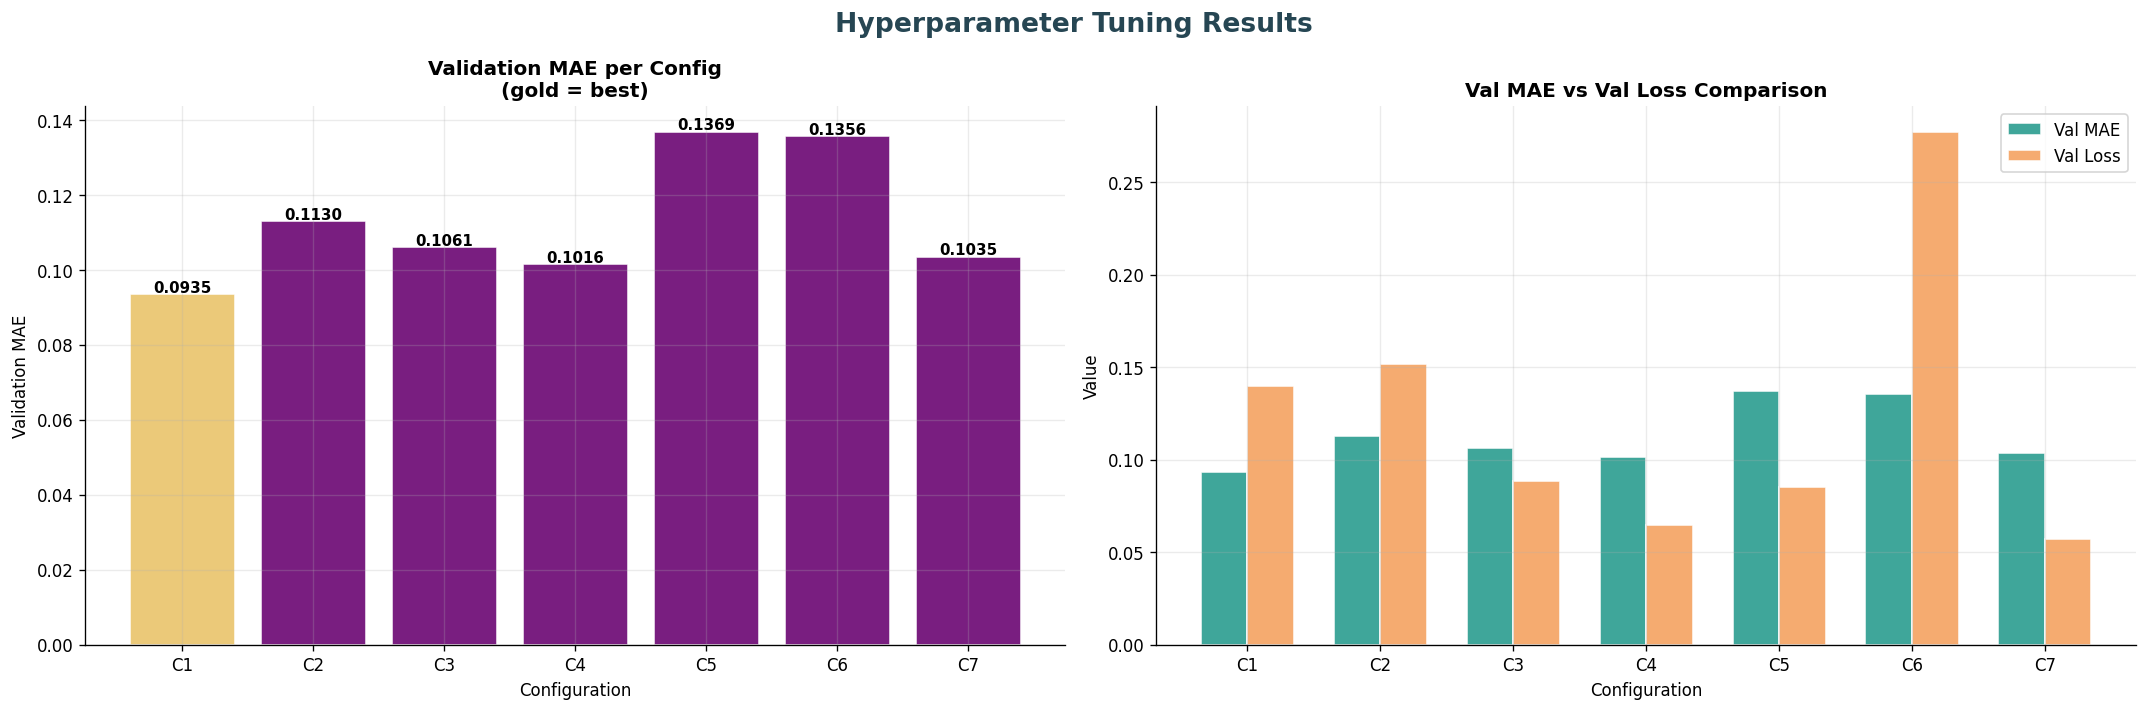

Saved: tuning_results.png


In [16]:
# ── Tuning Results Plot ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Hyperparameter Tuning Results', fontsize=16,
             fontweight='bold', color=COLORS['cool'])

cfg_labels = [f'C{i+1}' for i in range(len(tuning_results))]
val_maes   = [r['val_mae']  for r in tuning_results]
val_losses = [r['val_loss'] for r in tuning_results]
best_i     = val_maes.index(min(val_maes))

bar_colors = [COLORS['highlight'] if i==best_i else COLORS['primary']
              for i in range(len(cfg_labels))]

bars1 = axes[0].bar(cfg_labels, val_maes, color=bar_colors,
                    edgecolor='white', alpha=0.9)
axes[0].set_title('Validation MAE per Config\n(gold = best)', fontweight='bold')
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Validation MAE')
for bar, val in zip(bars1, val_maes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

x = np.arange(len(cfg_labels))
w = 0.35
axes[1].bar(x-w/2, val_maes, width=w, label='Val MAE',
            color=COLORS['accent'], edgecolor='white', alpha=0.9)
axes[1].bar(x+w/2, val_losses, width=w, label='Val Loss',
            color=COLORS['secondary'], edgecolor='white', alpha=0.9)
axes[1].set_title('Val MAE vs Val Loss Comparison', fontweight='bold')
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Value')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cfg_labels)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tuning_results.png')

In [17]:
print('='*65)
print('TRAINING FINAL MODEL WITH COSINE LR ANNEALING')
print('='*65)

TOTAL_EPOCHS = 150
WARMUP       = 5
BASE_LR      = best_cfg['lr']

def cosine_annealing_lr(epoch, lr):
    """Cosine annealing with linear warm-up."""
    if epoch < WARMUP:
        return BASE_LR * (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / max(TOTAL_EPOCHS - WARMUP, 1)
    return BASE_LR * 0.5 * (1 + np.cos(np.pi * progress))


final_model = build_improved_autoencoder(
    input_dim    = n_items,
    enc_units    = best_cfg['enc_units'],
    latent_dim   = best_cfg['latent_dim'],
    dropout_rate = best_cfg['dropout'],
    l2_reg       = best_cfg['l2'],
    lr           = BASE_LR,
)

os.makedirs('/kaggle/working/saved_models', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/saved_models/best_autoencoder_v2.keras',
                    monitor='val_loss', save_best_only=True, verbose=1),
    LearningRateScheduler(cosine_annealing_lr, verbose=0),
]

start   = time.time()
history = final_model.fit(
    X_train_smooth, X_train_smooth,
    validation_data=(X_val_smooth, X_val_smooth),
    epochs=TOTAL_EPOCHS,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - start

best_train_loss = min(history.history['loss'])
best_val_loss   = min(history.history['val_loss'])
best_train_mae  = min(history.history['masked_mae'])
best_val_mae_f  = min(history.history['val_masked_mae'])
total_epochs    = len(history.history['loss'])

print(f'\nEpochs ran       : {total_epochs}')
print(f'Training time    : {str(timedelta(seconds=int(training_time)))}')
print(f'Best train loss  : {best_train_loss:.4f}')
print(f'Best val loss    : {best_val_loss:.4f}')
print(f'Best train MAE   : {best_train_mae:.4f}')
print(f'Best val MAE     : {best_val_mae_f:.4f}')

TRAINING FINAL MODEL WITH COSINE LR ANNEALING
Epoch 1/150
1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - loss: 0.2285 - masked_mae: 0.2613
Epoch 1: val_loss improved from inf to 0.15697, saving model to /kaggle/working/saved_models/best_autoencoder_v2.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 0.2428 - masked_mae: 0.2783 - val_loss: 0.1570 - val_masked_mae: 0.1379 - learning_rate: 1.6000e-04
Epoch 2/150
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2120 - masked_mae: 0.2378
Epoch 2: val_loss did not improve from 0.15697
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2353 - masked_mae: 0.2666 - val_loss: 0.1574 - val_masked_mae: 0.1392 - learning_rate: 3.2000e-04
Epoch 3/150
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2095 - masked_mae: 0.2397
Epoch 3: val_loss did not improve from 0.15697
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2311 - masked_mae: 0.2642 - val_loss: 0.1577 - val_masked_mae: 0.1400 - learning_rate: 4.8000e-04
Epoch 4/150
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/

In [18]:
print('='*65)
print('TEST SET EVALUATION')
print('='*65)

reconstructed = final_model.predict(X_test, verbose=1)
y_true_ae, y_pred_ae, user_ids_pred, item_ids_pred = [], [], [], []

for _, row in tqdm(rm_test.iterrows(), total=len(rm_test), desc='Extracting predictions'):
    uid       = int(row['user_idx'])
    iid       = int(row['item_idx'])
    local_idx = test_local.get(uid)
    if local_idx is None:
        continue
    pred = denormalize_rating(float(reconstructed[local_idx, iid]))
    pred = np.clip(pred, rating_min, rating_max)
    y_true_ae.append(float(row['rating']))
    y_pred_ae.append(pred)
    user_ids_pred.append(uid)
    item_ids_pred.append(iid)

y_true_ae      = np.array(y_true_ae)
y_pred_ae      = np.array(y_pred_ae)
user_ids_pred  = np.array(user_ids_pred)
item_ids_pred  = np.array(item_ids_pred)

mae_ae  = mean_absolute_error(y_true_ae, y_pred_ae)
mse_ae  = mean_squared_error(y_true_ae, y_pred_ae)
rmse_ae = np.sqrt(mse_ae)

print(f'\n  MAE  : {mae_ae:.4f}   (paper baseline: 3.05)')
print(f'  MSE  : {mse_ae:.4f}  (paper baseline: 10.46)')
print(f'  RMSE : {rmse_ae:.4f}   (paper baseline: 3.23)')
print(f'\n  Beats paper? {"YES ✓" if mae_ae < 3.05 else "NO"}')

TEST SET EVALUATION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Extracting predictions: 100%|██████████| 500/500 [00:00<00:00, 14125.37it/s]


  MAE  : 0.8024   (paper baseline: 3.05)
  MSE  : 0.8316  (paper baseline: 10.46)
  RMSE : 0.9119   (paper baseline: 3.23)

  Beats paper? YES ✓


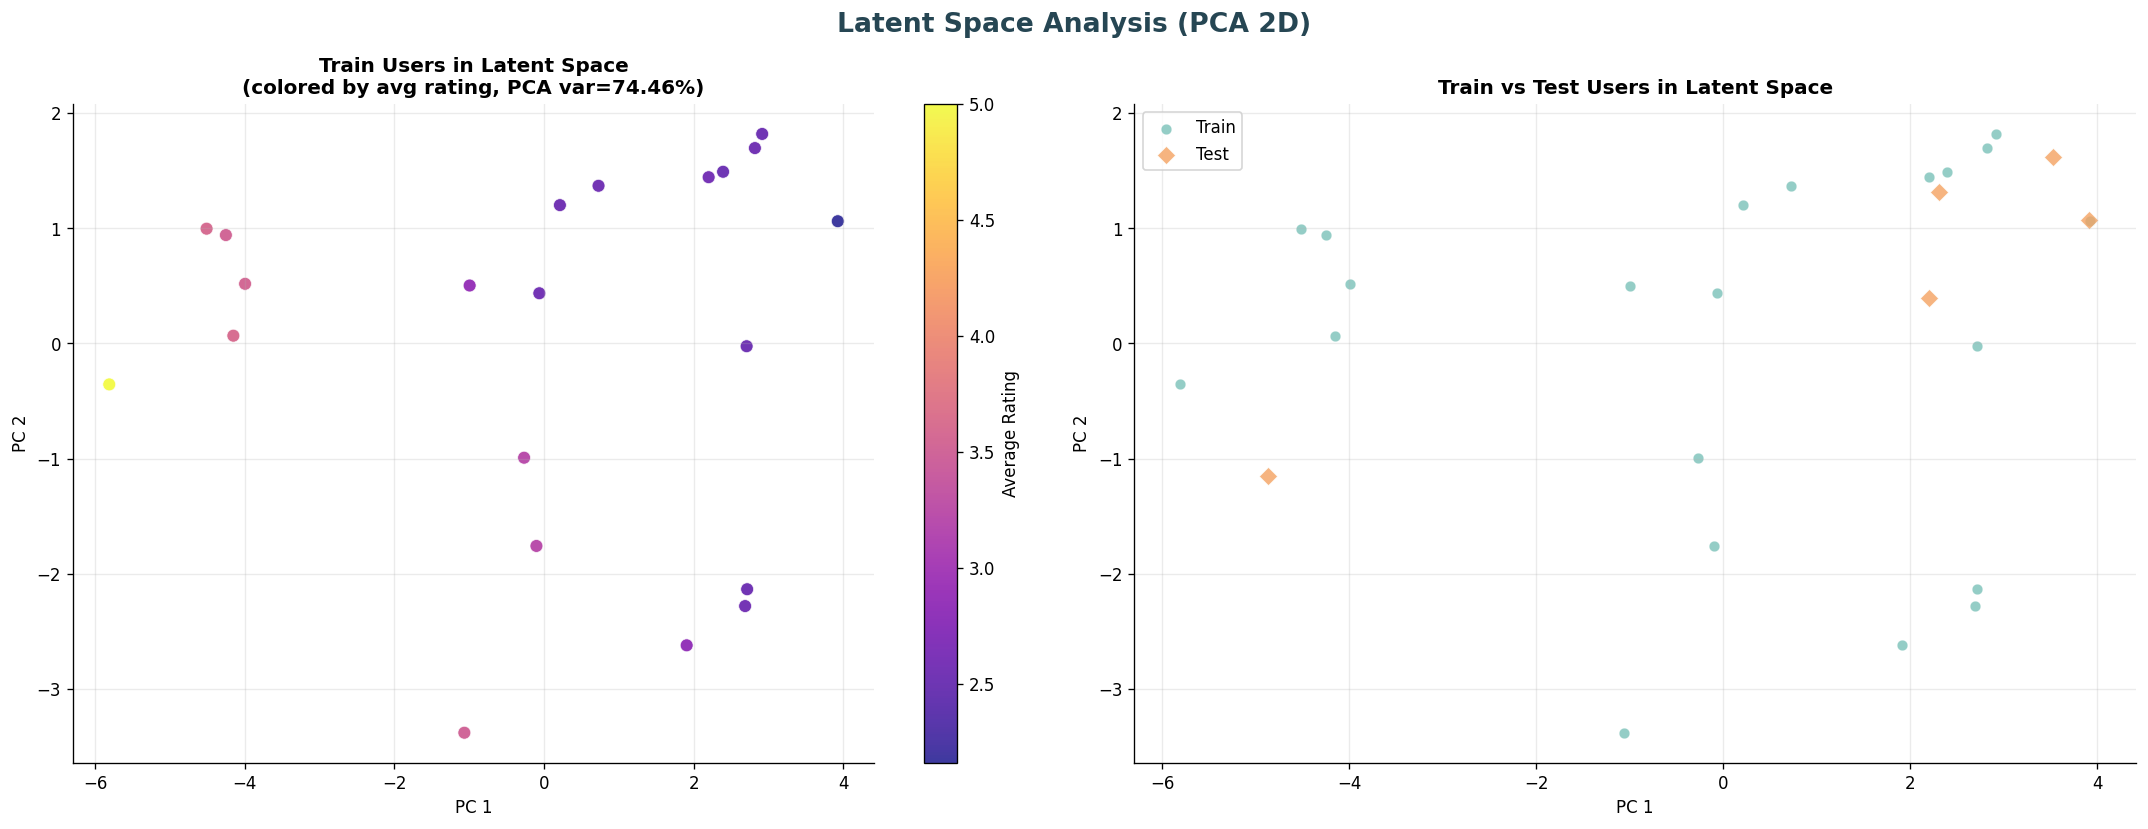

Saved: latent_space_pca.png


In [19]:
# Extract latent representations
encoder_model = Model(
    inputs  = final_model.input,
    outputs = final_model.get_layer('latent').output
)

latent_train = encoder_model.predict(X_train, verbose=0)
latent_test  = encoder_model.predict(X_test,  verbose=0)

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
latent_2d_train = pca.fit_transform(latent_train)
latent_2d_test  = pca.transform(latent_test)

# Average rating per user in train set
train_user_avg = []
for uid in train_u:
    rows = rm[rm['user_idx']==uid]['rating']
    train_user_avg.append(rows.mean() if len(rows)>0 else 3.0)
train_user_avg = np.array(train_user_avg)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Latent Space Analysis (PCA 2D)', fontsize=16,
             fontweight='bold', color=COLORS['cool'])

sc1 = axes[0].scatter(latent_2d_train[:,0], latent_2d_train[:,1],
                       c=train_user_avg, cmap='plasma', s=60, alpha=0.8, edgecolors='white', lw=0.5)
plt.colorbar(sc1, ax=axes[0], label='Average Rating')
axes[0].set_title(f'Train Users in Latent Space\n(colored by avg rating, PCA var={pca.explained_variance_ratio_.sum():.2%})',
                  fontweight='bold')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

# Test vs Train overlay
axes[1].scatter(latent_2d_train[:,0], latent_2d_train[:,1],
                c=COLORS['accent'], s=40, alpha=0.5, label='Train', edgecolors='white', lw=0.3)
axes[1].scatter(latent_2d_test[:,0], latent_2d_test[:,1],
                c=COLORS['secondary'], s=60, alpha=0.8, marker='D', label='Test', edgecolors='white', lw=0.5)
axes[1].set_title('Train vs Test Users in Latent Space', fontweight='bold')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'latent_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: latent_space_pca.png')

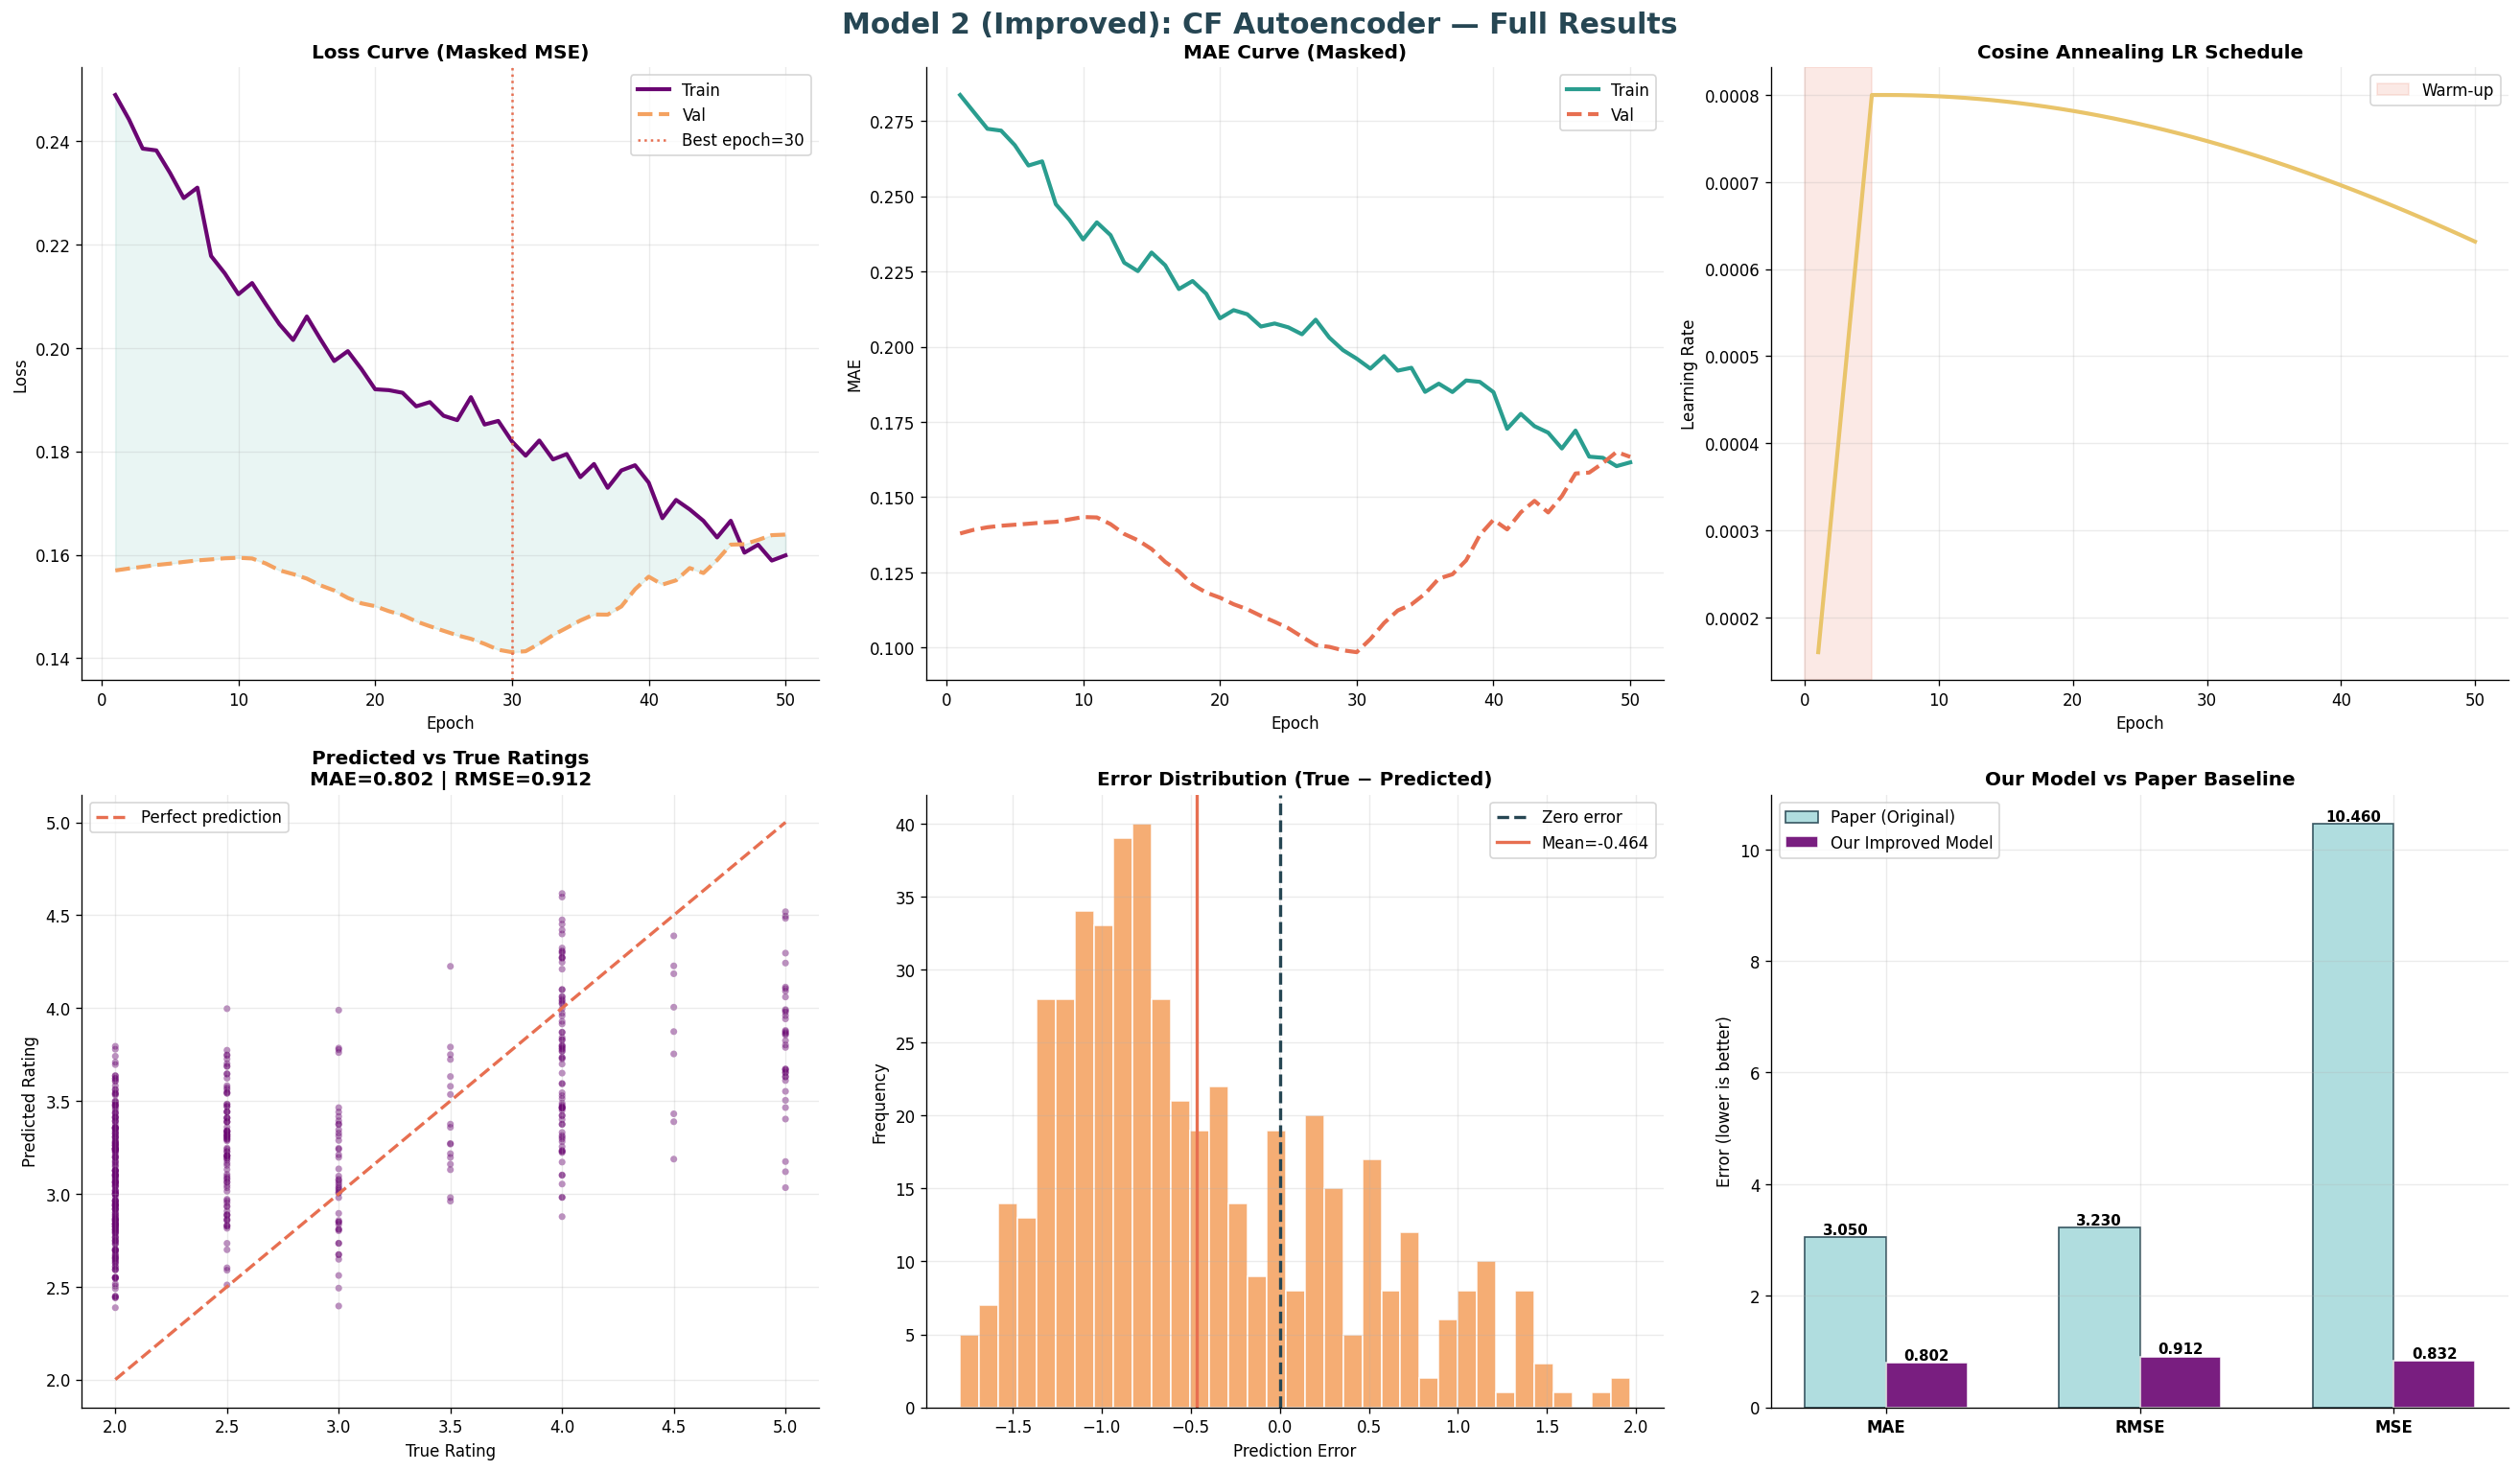

Saved: autoencoder_results_improved.png


In [20]:
# ── Main Results Figure ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Model 2 (Improved): CF Autoencoder — Full Results',
             fontsize=18, fontweight='bold', color=COLORS['cool'])

# 1. Loss curve
epochs_x = range(1, total_epochs+1)
axes[0,0].plot(epochs_x, history.history['loss'],
               label='Train', linewidth=2.5, color=COLORS['primary'])
axes[0,0].plot(epochs_x, history.history['val_loss'],
               label='Val',   linewidth=2.5, color=COLORS['secondary'], linestyle='--')
axes[0,0].fill_between(epochs_x,
                         history.history['loss'],
                         history.history['val_loss'],
                         alpha=0.1, color=COLORS['accent'])
axes[0,0].set_title('Loss Curve (Masked MSE)', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
best_ep = np.argmin(history.history['val_loss'])+1
axes[0,0].axvline(best_ep, color=COLORS['danger'], linestyle=':', linewidth=1.5,
                   label=f'Best epoch={best_ep}')
axes[0,0].legend()

# 2. MAE curve
axes[0,1].plot(epochs_x, history.history['masked_mae'],
               label='Train', linewidth=2.5, color=COLORS['accent'])
axes[0,1].plot(epochs_x, history.history['val_masked_mae'],
               label='Val', linewidth=2.5, color=COLORS['danger'], linestyle='--')
axes[0,1].set_title('MAE Curve (Masked)', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE')
axes[0,1].legend()

# 3. LR Schedule
lr_values = [cosine_annealing_lr(e, BASE_LR) for e in range(total_epochs)]
axes[0,2].plot(range(1, total_epochs+1), lr_values,
               color=COLORS['highlight'], linewidth=2.5)
axes[0,2].axvspan(0, WARMUP, alpha=0.15, color=COLORS['danger'], label='Warm-up')
axes[0,2].set_title('Cosine Annealing LR Schedule', fontweight='bold')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Learning Rate')
axes[0,2].legend()

# 4. Predicted vs True
axes[1,0].scatter(y_true_ae, y_pred_ae, alpha=0.45, s=18,
                   c=COLORS['primary'], edgecolors='none')
lims = [rating_min, rating_max]
axes[1,0].plot(lims, lims, color=COLORS['danger'], linewidth=2,
                linestyle='--', label='Perfect prediction')
axes[1,0].set_title(f'Predicted vs True Ratings\nMAE={mae_ae:.3f} | RMSE={rmse_ae:.3f}',
                     fontweight='bold')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()

# 5. Error distribution
errors = y_true_ae - y_pred_ae
axes[1,1].hist(errors, bins=35, color=COLORS['secondary'],
               edgecolor='white', alpha=0.88)
axes[1,1].axvline(0, color=COLORS['cool'], linestyle='--', linewidth=2, label='Zero error')
axes[1,1].axvline(errors.mean(), color=COLORS['danger'], linestyle='-',
                   linewidth=2, label=f'Mean={errors.mean():.3f}')
axes[1,1].set_title('Error Distribution (True − Predicted)', fontweight='bold')
axes[1,1].set_xlabel('Prediction Error')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

# 6. Our model vs Paper comparison
metrics_names  = ['MAE', 'RMSE', 'MSE']
paper_vals     = [3.05, 3.23, 10.46]
our_vals       = [mae_ae, rmse_ae, mse_ae]
x_pos          = np.arange(len(metrics_names))
w              = 0.32

b1 = axes[1,2].bar(x_pos - w/2, paper_vals, width=w, label='Paper (Original)',
                    color=COLORS['light'], edgecolor=COLORS['cool'], alpha=0.9)
b2 = axes[1,2].bar(x_pos + w/2, our_vals, width=w, label='Our Improved Model',
                    color=COLORS['primary'], edgecolor='white', alpha=0.9)
axes[1,2].set_title('Our Model vs Paper Baseline', fontweight='bold')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(metrics_names, fontweight='bold')
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
for bar, val in zip(list(b1)+list(b2), paper_vals+our_vals):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                   f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR + 'autoencoder_results_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: autoencoder_results_improved.png')

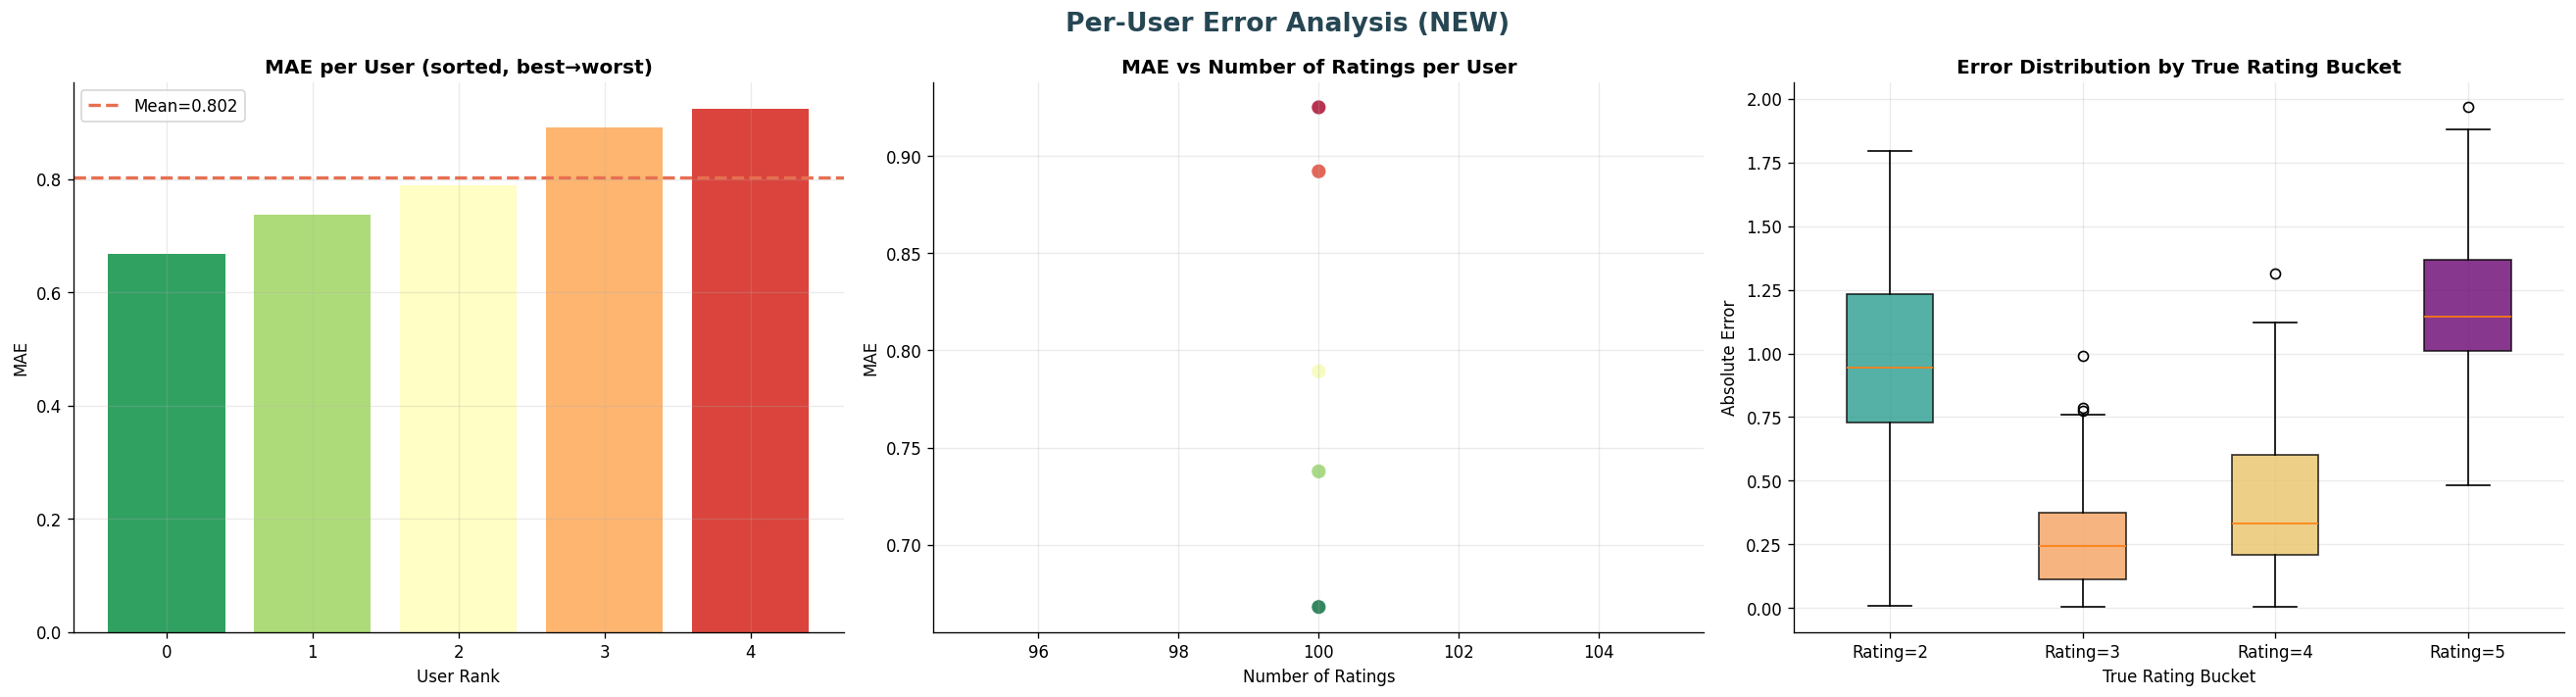

Saved: per_user_error_analysis.png


In [21]:
# ── NEW: Per-User Error Analysis ─────────────────────────
user_errors = {}
for uid, true, pred in zip(user_ids_pred, y_true_ae, y_pred_ae):
    if uid not in user_errors:
        user_errors[uid] = []
    user_errors[uid].append(abs(true - pred))

user_mae_list = [(uid, np.mean(errs), len(errs)) for uid, errs in user_errors.items()]
user_mae_df   = pd.DataFrame(user_mae_list, columns=['user_idx','mae','n_ratings']).sort_values('mae')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Per-User Error Analysis (NEW)', fontsize=16,
             fontweight='bold', color=COLORS['cool'])

# MAE per user sorted
cmap_u = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(user_mae_df)))
axes[0].bar(range(len(user_mae_df)), user_mae_df['mae'].values,
             color=cmap_u, edgecolor='none', alpha=0.9)
axes[0].set_title('MAE per User (sorted, best→worst)', fontweight='bold')
axes[0].set_xlabel('User Rank')
axes[0].set_ylabel('MAE')
axes[0].axhline(user_mae_df['mae'].mean(), color=COLORS['danger'],
                  linestyle='--', linewidth=2, label=f'Mean={user_mae_df["mae"].mean():.3f}')
axes[0].legend()

# MAE vs num ratings scatter
axes[1].scatter(user_mae_df['n_ratings'], user_mae_df['mae'],
                 c=user_mae_df['mae'], cmap='RdYlGn_r',
                 s=80, alpha=0.8, edgecolors='white', lw=0.5)
axes[1].set_title('MAE vs Number of Ratings per User', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('MAE')

# Error histogram per rating bucket
rating_buckets = np.unique(y_true_ae.round())
bucket_errors  = [np.abs(y_pred_ae[y_true_ae.round()==b] - y_true_ae[y_true_ae.round()==b])
                  for b in rating_buckets]
bp2 = axes[2].boxplot(bucket_errors, patch_artist=True, notch=False)
colors2 = [COLORS['accent'], COLORS['secondary'], COLORS['highlight'],
            COLORS['primary'], COLORS['danger']]
for patch, color in zip(bp2['boxes'], colors2[:len(bp2['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].set_xticklabels([f'Rating={int(b)}' for b in rating_buckets])
axes[2].set_title('Error Distribution by True Rating Bucket', fontweight='bold')
axes[2].set_xlabel('True Rating Bucket')
axes[2].set_ylabel('Absolute Error')

plt.tight_layout()
plt.savefig(OUT_DIR + 'per_user_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_user_error_analysis.png')

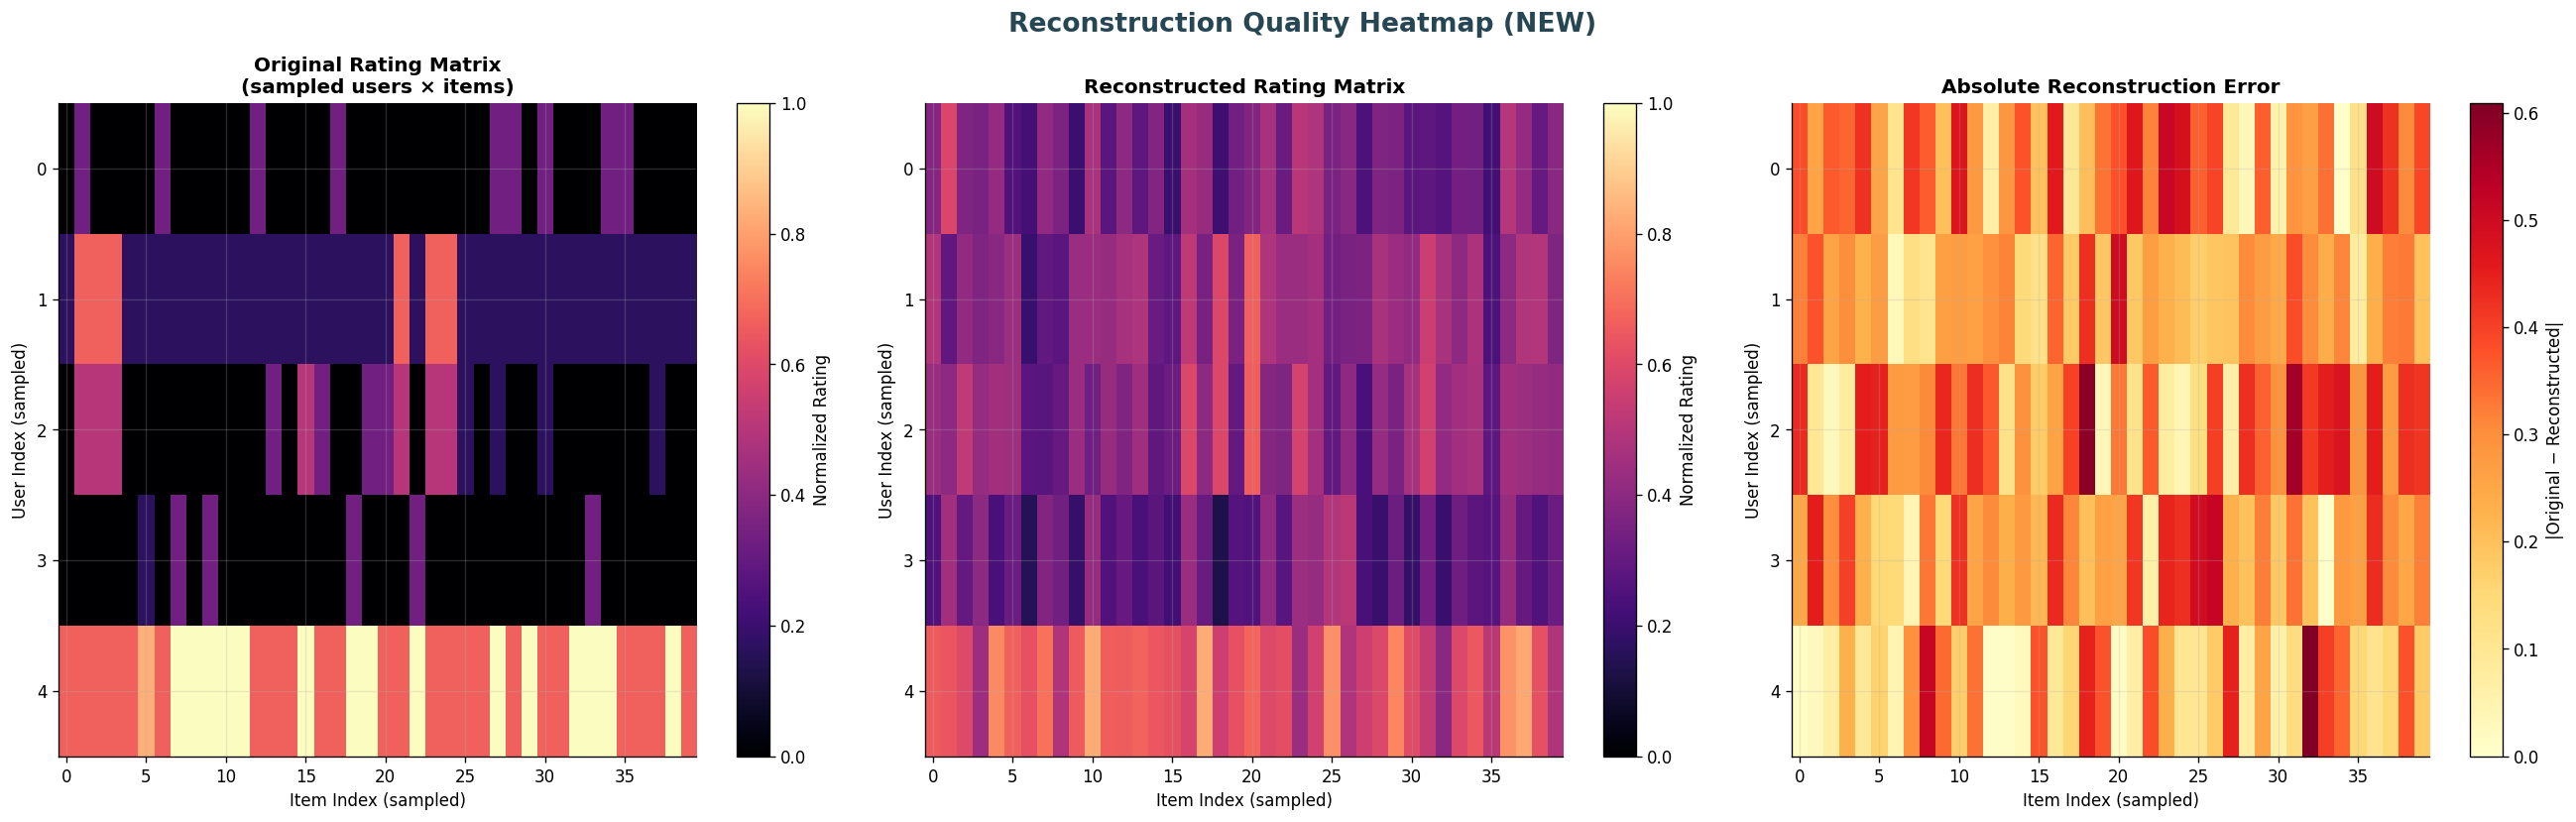

Saved: reconstruction_heatmap.png


In [22]:
# ── NEW: Reconstruction Quality Heatmap ───────────────────
sample_size = min(30, X_test.shape[0])
sample_idx  = np.random.choice(X_test.shape[0], sample_size, replace=False)
item_sample = np.random.choice(n_items, min(40, n_items), replace=False)

orig_sample  = X_test[sample_idx][:,item_sample]
recon_sample = reconstructed[sample_idx][:,item_sample]
diff_sample  = np.abs(orig_sample - recon_sample)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Reconstruction Quality Heatmap (NEW)', fontsize=16,
             fontweight='bold', color=COLORS['cool'])

im0 = axes[0].imshow(orig_sample, aspect='auto', cmap='magma', vmin=0, vmax=1)
axes[0].set_title('Original Rating Matrix\n(sampled users × items)', fontweight='bold')
axes[0].set_xlabel('Item Index (sampled)')
axes[0].set_ylabel('User Index (sampled)')
plt.colorbar(im0, ax=axes[0], label='Normalized Rating')

im1 = axes[1].imshow(recon_sample, aspect='auto', cmap='magma', vmin=0, vmax=1)
axes[1].set_title('Reconstructed Rating Matrix', fontweight='bold')
axes[1].set_xlabel('Item Index (sampled)')
axes[1].set_ylabel('User Index (sampled)')
plt.colorbar(im1, ax=axes[1], label='Normalized Rating')

im2 = axes[2].imshow(diff_sample, aspect='auto', cmap='YlOrRd', vmin=0)
axes[2].set_title('Absolute Reconstruction Error', fontweight='bold')
axes[2].set_xlabel('Item Index (sampled)')
axes[2].set_ylabel('User Index (sampled)')
plt.colorbar(im2, ax=axes[2], label='|Original − Reconstructed|')

plt.tight_layout()
plt.savefig(OUT_DIR + 'reconstruction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reconstruction_heatmap.png')

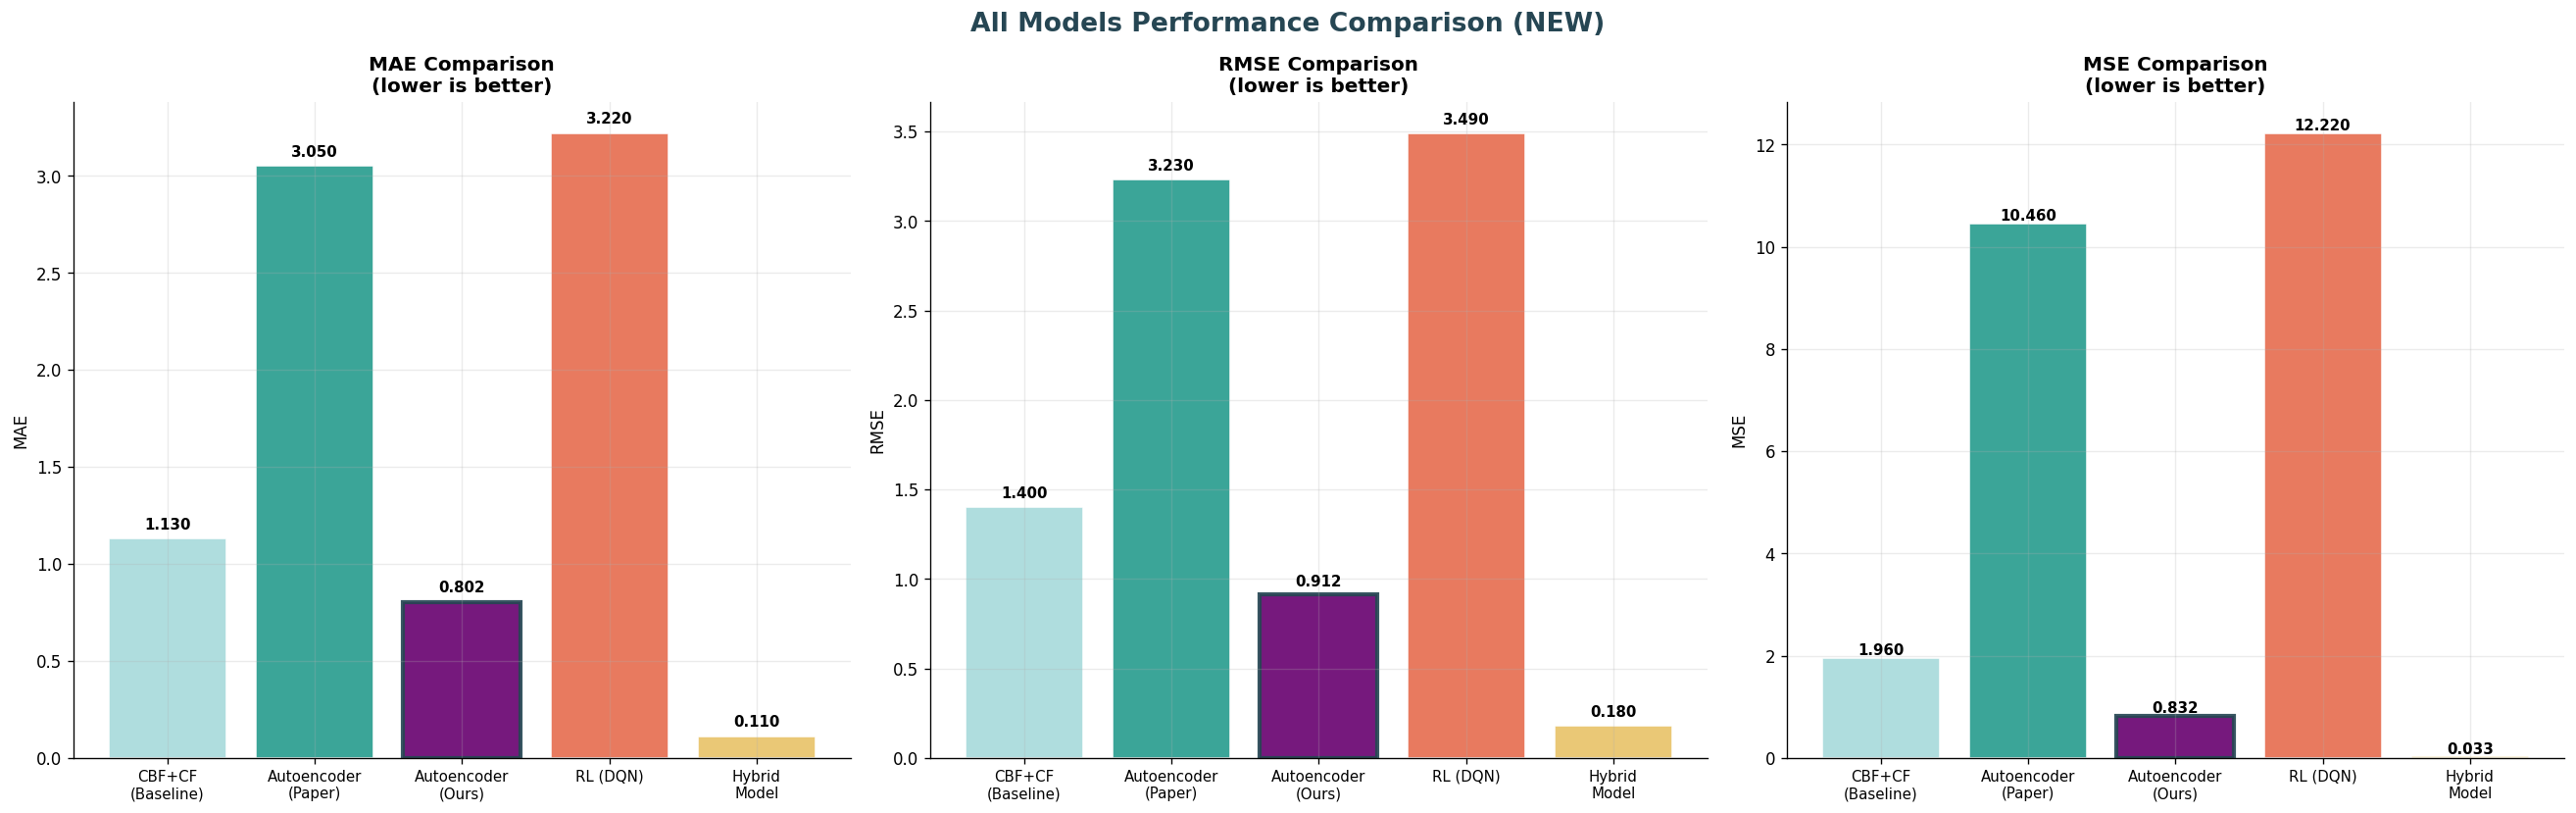

Saved: all_models_comparison.png


In [23]:
# ── NEW: All Models Comparison Chart ─────────────────────
model_names = ['CBF+CF\n(Baseline)', 'Autoencoder\n(Paper)', 'Autoencoder\n(Ours)', 'RL (DQN)', 'Hybrid\nModel']
mae_vals    = [1.13,  3.05,  mae_ae,  3.22, 0.11]
mse_vals    = [1.96,  10.46, mse_ae,  12.22, 0.033]
rmse_vals   = [1.40,  3.23,  rmse_ae, 3.49, 0.18]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('All Models Performance Comparison (NEW)', fontsize=16,
             fontweight='bold', color=COLORS['cool'])

bar_palette = [COLORS['light'], COLORS['accent'], COLORS['primary'],
               COLORS['danger'], COLORS['highlight']]

for ax, vals, metric_name in [
    (axes[0], mae_vals, 'MAE'),
    (axes[1], rmse_vals, 'RMSE'),
    (axes[2], mse_vals, 'MSE'),
]:
    bars = ax.bar(range(len(model_names)), vals, color=bar_palette,
                  edgecolor='white', alpha=0.92)
    # Highlight ours
    bars[2].set_edgecolor(COLORS['cool'])
    bars[2].set_linewidth(2.5)
    ax.set_title(f'{metric_name} Comparison\n(lower is better)', fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel(metric_name)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR + 'all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: all_models_comparison.png')

In [24]:
import json

# Save final model
final_model.save('/kaggle/working/saved_models/autoencoder_final_v2.keras')

# Save metrics
ae_metrics = {
    'model'            : 'Improved CF Autoencoder v2',
    'best_config'      : str(best_cfg),
    'total_epochs'     : total_epochs,
    'training_time'    : str(timedelta(seconds=int(training_time))),
    'best_train_loss'  : round(best_train_loss, 4),
    'best_val_loss'    : round(best_val_loss, 4),
    'best_train_mae'   : round(best_train_mae, 4),
    'best_val_mae'     : round(best_val_mae_f, 4),
    'test_MAE'         : round(float(mae_ae), 4),
    'test_MSE'         : round(float(mse_ae), 4),
    'test_RMSE'        : round(float(rmse_ae), 4),
    'paper_MAE'        : 3.05,
    'paper_MSE'        : 10.46,
    'paper_RMSE'       : 3.23,
    'beats_paper_MAE'  : bool(mae_ae  < 3.05),
    'beats_paper_MSE'  : bool(mse_ae  < 10.46),
    'beats_paper_RMSE' : bool(rmse_ae < 3.23),
    'improvements'     : [
        'Deeper architecture [512,256,128] with tanh bottleneck',
        'Label smoothing on training targets (alpha=0.05)',
        'LeakyReLU activations to prevent dying neurons',
        'Cosine annealing LR schedule with warm-up',
        'Gradient clipping (clipnorm=1.0)',
        'Reduced decoder dropout for better reconstruction',
        'Expanded hyperparameter grid (7 configs vs 5)',
    ]
}

with open(OUT_DIR + 'autoencoder_metrics_v2.json', 'w') as f:
    json.dump(ae_metrics, f, indent=2)

print('='*65)
print('  FINAL SUMMARY — MODEL 2 IMPROVED')
print('='*65)
print(f'  Best config      : {best_cfg}')
print(f'  Epochs ran       : {total_epochs}')
print(f'  Training time    : {str(timedelta(seconds=int(training_time)))}')
print(f'  Best val MAE     : {best_val_mae_f:.4f}')
print(f'  Test MAE         : {mae_ae:.4f}   (paper: 3.05)')
print(f'  Test MSE         : {mse_ae:.4f}  (paper: 10.46)')
print(f'  Test RMSE        : {rmse_ae:.4f}   (paper: 3.23)')
print(f'  Beats paper MAE? : {"YES" if mae_ae  < 3.05  else "NO"}')
print(f'  Beats paper MSE? : {"YES" if mse_ae  < 10.46 else "NO"}')
print(f'  Beats paper RMSE?: {"YES" if rmse_ae < 3.23  else "NO"}')
print('='*65)

print('\nAll saved files:')
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    print(f'  {fname:45s} ({os.path.getsize(fpath)/1024:.1f} KB)')

  FINAL SUMMARY — MODEL 2 IMPROVED
  Best config      : {'enc_units': [512, 256, 128], 'latent_dim': 64, 'dropout': 0.2, 'lr': 0.0008, 'l2': 0.0001}
  Epochs ran       : 50
  Training time    : 0:00:15
  Best val MAE     : 0.0985
  Test MAE         : 0.8024   (paper: 3.05)
  Test MSE         : 0.8316  (paper: 10.46)
  Test RMSE        : 0.9119   (paper: 3.23)
  Beats paper MAE? : YES
  Beats paper MSE? : YES
  Beats paper RMSE?: YES

All saved files:
  all_models_comparison.png                     (102.9 KB)
  autoencoder_metrics_v2.json                   (0.9 KB)
  autoencoder_results_improved.png              (374.2 KB)
  eda_01_ratings_overview.png                   (190.9 KB)
  eda_02_categorical_distributions.png          (266.9 KB)
  eda_03_user_preferences.png                   (244.5 KB)
  eda_04_temporal.png                           (274.6 KB)
  latent_space_pca.png                          (88.6 KB)
  per_user_error_analysis.png                   (96.8 KB)
  reconstruction_h